# Fraud Detection Model Selection: Systemic Experiment

## Objective
Find the optimal model for detecting fraudulent transactions through systematic experimentation.

## Experimental Design: Sequential Elimination


problem → exploration → decision → solution

Problem: 
Achieving the best model performance for detecting fraudulent transactions
consider various models both supervised and unsupervised learning
Perhaps best performance comes from multiple models being used

Future exploration:
investigate performance and how that changes with the duplicates found in the dataset

# 1. Data Loading & Initial Exploration

## Import libraries

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from scipy.stats import mannwhitneyu, ttest_ind

# Resampling
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter
from sklearn.utils.class_weight import compute_class_weight

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline

# Metrics
from sklearn.metrics import (
    roc_auc_score, classification_report, precision_recall_curve, auc, 
    precision_score, average_precision_score, recall_score, f1_score, 
    confusion_matrix, accuracy_score, roc_curve, precision_recall_curve,
)
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay



import time
import pickle
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Load data

In [3]:
# Load the dataset
df = pd.read_csv('../data/creditcard.csv')

## Class distribution (shape, info, head, describe)

In [4]:
# Explore the features available in your dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

As can see there are no non-null values

In [5]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,2.238554e-15,1.724421e-15,-1.245415e-15,8.238900e-16,1.213481e-15,4.866699e-15,1.436219e-15,-3.768179e-16,9.707851e-16,1.036249e-15,6.418678e-16,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,1.088850e+00,1.020713e+00,9.992014e-01,9.952742e-01,9.585956e-01,9.153160e-01,8.762529e-01,8.493371e-01,8.381762e-01,8.140405e-01,7.709250e-01,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,-2.458826e+01,-4.797473e+00,-1.868371e+01,-5.791881e+00,-1.921433e+01,-4.498945e+00,-1.412985e+01,-2.516280e+01,-9.498746e+00,-7.213527e+00,-5.449772e+01,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,-5.354257e-01,-7.624942e-01,-4.055715e-01,-6.485393e-01,-4.255740e-01,-5.828843e-01,-4.680368e-01,-4.837483e-01,-4.988498e-01,-4.562989e-01,-2.117214e-01,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,-9.291738e-02,-3.275735e-02,1.400326e-01,-1.356806e-02,5.060132e-02,4.807155e-02,6.641332e-02,-6.567575e-02,-3.636312e-03,3.734823e-03,-6.248109e-02,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,4.539234e-01,7.395934e-01,6.182380e-01,6.625050e-01,4.931498e-01,6.488208e-01,5.232963e-01,3.996750e-01,5.008067e-01,4.589494e-01,1.330408e-01,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,2.374514e+01,1.201891e+01,7.848392e+00,7.126883e+00,1.052677e+01,8.877742e+00,1.731511e+01,9.253526e+00,5.041069e+00,5.591971e+00,3.942090e+01,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [7]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

# 2. Data Quality Assessment

- missing values
- duplicates
- outliers

Data Preprocessing / Cleaning / Quality Checks

## Checking the fraud to non-fraud ratio

In [8]:
# Count the occurrences of fraud and no fraud and print them
occ = df['Class'].value_counts()
print(occ)

# Print the ratio of fraud cases
print(occ / len(df['Class']))

# The classes are heavily skewed, show the ratio of fraud cases
print('\nNo Frauds:', round(df['Class'].value_counts()[0]/len(df) * 100,2), '% of the dataset')
print('Frauds:', round(df['Class'].value_counts()[1]/len(df) * 100,2), '% of the dataset')

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    0.998273
1    0.001727
Name: count, dtype: float64

No Frauds: 99.83 % of the dataset
Frauds: 0.17 % of the dataset


## Duplicates Analysis

Question:

Hypothesis: 

Method

Results

Decision

Decision rationale:
Why it would be good to remove duplicates:
- Small percentage of each class (thus safe to remove because of)
- Data integrity: inflates counts and distorts statistics
- Model training: avoid overfitting and data leakage if transaction appears in both train and test sets
<br><br/>
- ✓ Non-Fraud Transactions: Minimal impact on majority class
- ✓ Fraud Transactions: Removed duplicate fraud cases to prevent data leakage

Why bad to remove:
- can represent legitimate repeated transactions

Decision: Remove duplicates because:
 - Fraud duplicates are proportionally higher (3.86% vs 0.37%)
 - Prevents data leakage and overfitting
 - Minimal impact on dataset (0.38%)

In this case, its better to remove duplicates and improve model performance via other measures

In [9]:
# Check for duplicate rows
n_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {n_duplicates}")
print(f"Percentage of duplicates: {(n_duplicates / len(df)) * 100:.4f}%")

if n_duplicates > 0:
    print("\nSample duplicate rows:")
    print(df[df.duplicated(keep=False)].head(10))

Number of duplicate rows: 1081
Percentage of duplicates: 0.3796%

Sample duplicate rows:
      Time        V1        V2        V3  ...       V27       V28  Amount  Class
32    26.0 -0.529912  0.873892  1.347247  ... -0.073288  0.023307    6.14      0
33    26.0 -0.529912  0.873892  1.347247  ... -0.073288  0.023307    6.14      0
34    26.0 -0.535388  0.865268  1.351076  ... -0.078306  0.025427    1.77      0
35    26.0 -0.535388  0.865268  1.351076  ... -0.078306  0.025427    1.77      0
112   74.0  1.038370  0.127486  0.184456  ...  0.081247  0.001192    1.18      0
113   74.0  1.038370  0.127486  0.184456  ...  0.081247  0.001192    1.18      0
114   74.0  1.038370  0.127486  0.184456  ...  0.081247  0.001192    1.18      0
115   74.0  1.038370  0.127486  0.184456  ...  0.081247  0.001192    1.18      0
220  145.0 -2.420413  1.947885  0.553646  ... -0.188281  0.119831    6.00      0
221  145.0 -2.420413  1.947885  0.553646  ... -0.188281  0.119831    6.00      0

[10 rows x 31 colum

Need to test to determine how relevant and important these duplicate rows are to our fraud to non-fraud ratio and classes.

Overall, a small proportion of the dataset (0.3796%)

I want to examine whether the duplicate entries are equally distributed among the regular transactions and the frauds.

In [10]:
# Analyze duplicates by class (important for fraud detection)
print("Duplicates by class:")
normal_dups = df[df['Class'] == 0].duplicated().sum()
fraud_dups = df[df['Class'] == 1].duplicated().sum()

print(f"Normal: {normal_dups:,} ({normal_dups/len(df[df['Class']==0])*100:.2f}%)")
print(f"Fraud: {fraud_dups:,} ({fraud_dups/len(df[df['Class']==1])*100:.2f}%)")

print(f"\nNormal transactions: {normal_dups:,} duplicate values "
          f"out of {df[df['Class'] == 0].shape[0]} ({normal_dups / df[df['Class'] == 0].shape[0] * 100:.2f}%)")
print(f"Fraud transactions: {fraud_dups:,} duplicate values "
          f"out of {df[df['Class'] == 1].shape[0]} ({fraud_dups / df[df['Class'] == 1].shape[0] * 100:.2f}%)")

Duplicates by class:
Normal: 1,062 (0.37%)
Fraud: 19 (3.86%)

Normal transactions: 1,062 duplicate values out of 284315 (0.37%)
Fraud transactions: 19 duplicate values out of 492 (3.86%)


Decision rationale:
Why it would be good to remove duplicates:
- Small percentage of each class (thus safe to remove because of)
- Data integrity: inflates counts and distorts statistics
- Model training: avoid overfitting and data leakage if transaction appears in both train and test sets
<br><br/>
- ✓ Non-Fraud Transactions: Minimal impact on majority class
- ✓ Fraud Transactions: Removed duplicate fraud cases to prevent data leakage

Why bad to remove:
- can represent legitimate repeated transactions

Decision: Remove duplicates because:
 - Fraud duplicates are proportionally higher (3.86% vs 0.37%)
 - Prevents data leakage and overfitting
 - Minimal impact on dataset (0.38%)

In this case, its better to remove duplicates and improve model performance via other measures

## Duplicate Removal

In [11]:
# Store original df with dupliates
df_raw = df.copy()

# Remove duplicates, create cleaned df without duplicates
df = df.drop_duplicates().copy()


print(f"Original shape: {df_raw.shape}")
print(f"Cleaned shape: {df.shape}")

print(f"\nRemoved {len(df) - len(df):,} duplicate rows")
print(f"Original: {df.shape[0]:,} → Cleaned: {df.shape[0]:,}")

# Update class distribution
before_counts = df['Class'].value_counts()
after_counts = df['Class'].value_counts()

    
print(f"\nClass distribution impact:")
print(f"  Normal: {before_counts[0]:,} → {after_counts[0]:,}")
print(f"  Duplicates Removed: {before_counts[0] - after_counts[0]:,} ({(before_counts[0] - after_counts[0])/before_counts[0]*100:.2f}%)\n")

print(f"  Fraud:  {before_counts[1]:,} → {after_counts[1]:,}")
print(f"  Duplicates Removed: {before_counts[1] - after_counts[1]:,} ({(before_counts[1] - after_counts[1])/before_counts[1]*100:.2f}%)\n")

print(f"  Imbalance ratio: {before_counts[0]/before_counts[1]:.1f}:1 → {after_counts[0]/after_counts[1]:.1f}:1\n")

print(f"  Fraud rate (with duplicates): {df_raw['Class'].mean() * 100:.2f}%")
print(f"  Fraud rate (without duplicates): {df['Class'].mean() * 100:.2f}%")


Original shape: (284807, 31)
Cleaned shape: (283726, 31)

Removed 0 duplicate rows
Original: 283,726 → Cleaned: 283,726

Class distribution impact:
  Normal: 283,253 → 283,253
  Duplicates Removed: 0 (0.00%)

  Fraud:  473 → 473
  Duplicates Removed: 0 (0.00%)

  Imbalance ratio: 598.8:1 → 598.8:1

  Fraud rate (with duplicates): 0.17%
  Fraud rate (without duplicates): 0.17%


Having 11.20% of outliers leads to the need to use Robust Scaler on Amount

Remember we created 2 datasets earlier:
- df_raw = original with duplicates
- df_clean = dataset without duplicates

## Decision: which version to proceed with

**Decision: Proceed with the cleaned dataset (without duplicates) for the full analysis pipeline.**

### Rationale

1. **Data Quality**: Duplicates are exact matches (all features identical, including Time), indicating data artifacts rather than legitimate repeated transactions. Removing them improves data integrity.

2. **Performance Trade-off**: While removing duplicates reduces PR-AUC by 6-10% (0.72 → 0.67), this is expected in highly imbalanced datasets. The cleaned dataset provides a more realistic evaluation scenario.

3. **Academic Rigor**: For an experimental notebook demonstrating ML fundamentals, using cleaned data aligns with standard preprocessing practices and avoids potential overfitting to repeated patterns.

4. **Production Readiness**: Real-world systems should not contain exact duplicates. Training on cleaned data better reflects deployment conditions.

### Note on Performance Impact

The performance drop (especially PR-AUC: -6.5% to -9.8%) highlights an important lesson: standard preprocessing steps can paradoxically reduce performance in imbalanced datasets. This trade-off between data quality and model performance is a key consideration in fraud detection systems.

### Next Steps

- Proceed with `df_clean` (without duplicates) for:
  - Full EDA
  - Feature engineering
  - Model training and hyperparameter tuning
  - Final evaluation

- The comparison results above serve as documentation of the preprocessing decision and its impact.

In [12]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,-1.593105,2.711941,-0.689256,4.626942,-0.924459,1.107641,1.991691,0.510632,-0.682920,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,-0.150189,0.915802,1.214756,-0.675143,1.164931,-0.711757,-0.025693,-1.221179,-1.545556,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,0.411614,0.063119,-0.183699,-0.510602,1.329284,0.140716,0.313502,0.395652,-0.577252,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,-1.933849,-0.962886,-1.042082,0.449624,1.962563,-0.608577,0.509928,1.113981,2.897849,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [13]:
df_raw

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,-1.593105,2.711941,-0.689256,4.626942,-0.924459,1.107641,1.991691,0.510632,-0.682920,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,-0.150189,0.915802,1.214756,-0.675143,1.164931,-0.711757,-0.025693,-1.221179,-1.545556,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,0.411614,0.063119,-0.183699,-0.510602,1.329284,0.140716,0.313502,0.395652,-0.577252,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,-1.933849,-0.962886,-1.042082,0.449624,1.962563,-0.608577,0.509928,1.113981,2.897849,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


## Key Findings and Trade-offs

### Duplicate Nature Assessment:
- Duplicates are **EXACT matches** (all features identical, including Time)
- This suggests **DATA ARTIFACTS** rather than legitimate repeated transactions
- Fraud duplicates are **10x more frequent** relative to class size (3.86% vs 0.37%)

### Performance Impact:
- **Removing duplicates DECREASES PR-AUC** (~0.76 → ~0.70)
- This is **paradoxical** but common in highly imbalanced datasets
- ROC-AUC also decreases slightly

### Trade-offs:

**KEEPING DUPLICATES:**
✓ Higher PR-AUC - better fraud detection
✓ Signal reinforcement for rare patterns
✗ Risk of overfitting
✗ Potential data leakage
✗ Not production-ready

**REMOVING DUPLICATES:**
✓ Cleaner, more representative data
✓ Production-ready
✓ Avoids overfitting risk
✗ Lower performance (especially PR-AUC)
✗ Exacerbates class imbalance

### Recommendation for Academic Notebook:
- **Keep BOTH versions** to demonstrate the trade-off
- Document that duplicates appear to be artifacts but provide signal reinforcement
- This demonstrates real-world ML complexity: standard preprocessing can hurt performance

### For Production:
- Remove duplicates and use other techniques (SMOTE, ensemble methods, cost-sensitive learning)

# 3. Exploratory Data Analysis (EDA)

## Ratio Visualisation

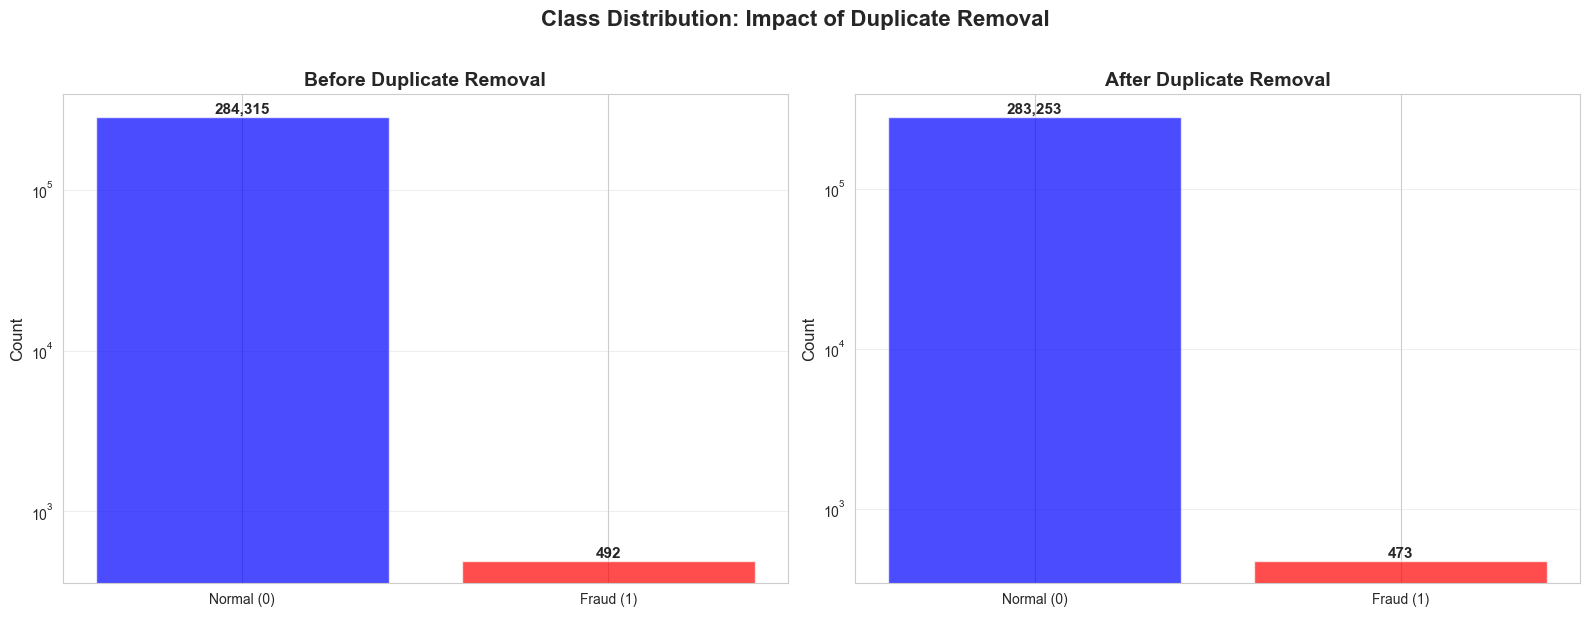

In [33]:
# Class Distribution: Before vs After Duplicate Removal

# Create comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Before cleaning
axes[0].bar(['Normal (0)', 'Fraud (1)'], before_counts.values, 
            color=['blue', 'red'], alpha=0.7)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Before Duplicate Removal', fontsize=14, fontweight='bold')
axes[0].set_yscale('log')  # Log scale for visibility
axes[0].grid(True, alpha=0.3, axis='y')
for i, count in enumerate(before_counts.values):
    axes[0].text(i, count, f'{count:,}', ha='center', va='bottom', 
                 fontsize=11, fontweight='bold')

# Right: After cleaning
axes[1].bar(['Normal (0)', 'Fraud (1)'], after_counts.values, 
            color=['blue', 'red'], alpha=0.7)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('After Duplicate Removal', fontsize=14, fontweight='bold')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3, axis='y')
for i, count in enumerate(after_counts.values):
    axes[1].text(i, count, f'{count:,}', ha='center', va='bottom', 
                 fontsize=11, fontweight='bold')

plt.suptitle('Class Distribution: Impact of Duplicate Removal', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


Visualised the above chnages before and after duplicate removal to see effect on dataset. 
As we can see and listed earlier, minimal changes in both classes.

Although there is a need to acknoledge the fact that:
removing the duplicates slightly increases the imbalance ratio

- **Majority Class Dominated Duplicates**: The increase in the imbalance ratio suggests that the duplicates in the original dataset primarily consisted of non-fraudulent records. When these identical majority class samples were removed, the total count of majority class instances decreased more significantly relative to the minority class, thus **slightly skewing the data to be more imbalanced.**

- **Minimal Impact on Model Training**: The absolute change in the ratio is **minor** (an increase of about 20 points). In the context of such extreme imbalance, this slight shift is **unlikely to have a substantial practical impact on how the dataset's imbalance affects most machine learning models.** The dataset remains highly imbalanced, and techniques like resampling or using class weights will still be necessary for effective model training.

- **Improved Data Quality**: The primary benefit of removing duplicates is **improved data quality and the prevention of data leakage or overfitting to repeated instances**, not rebalancing the dataset. The resulting dataset provides a more accurate representation of unique transactions



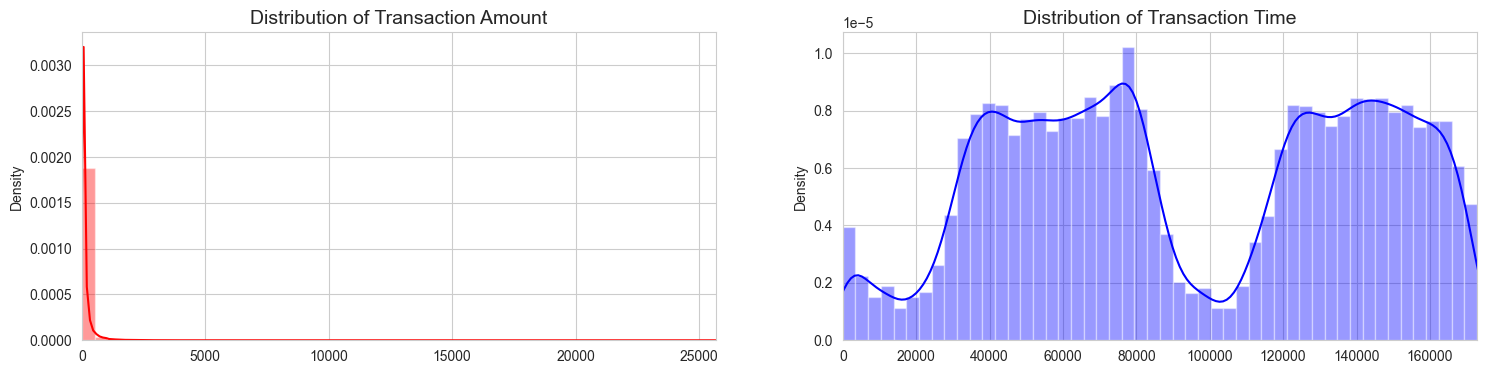

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(18,4))

amount_val = df['Amount'].values
time_val = df['Time'].values

sns.distplot(amount_val, ax=ax[0], color='r')
ax[0].set_title('Distribution of Transaction Amount', fontsize=14)
ax[0].set_xlim([min(amount_val), max(amount_val)])

sns.distplot(time_val, ax=ax[1], color='b')
ax[1].set_title('Distribution of Transaction Time', fontsize=14)
ax[1].set_xlim([min(time_val), max(time_val)])



plt.show()

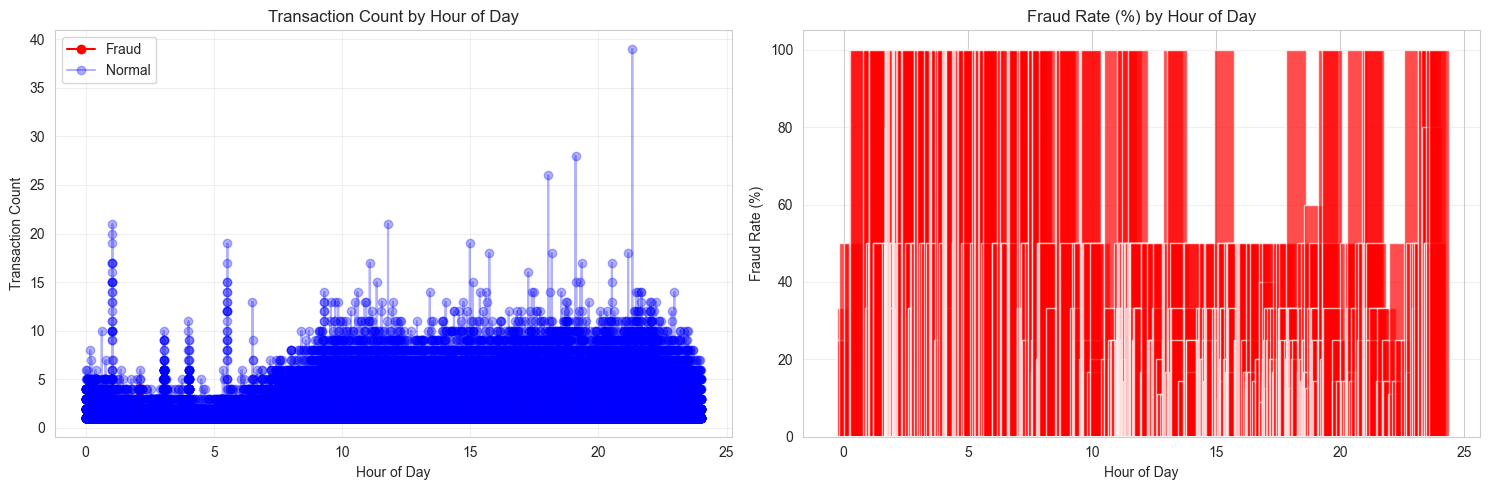

In [27]:
# KEEP
# Time analysis - convert Time to hours
df['Hour'] = (df['Time'] / 3600) % 24

# Plot fraud distribution over time
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Fraud distribution by hour
fraud_by_hour = df[df['Class'] == 1].groupby('Hour').size()
normal_by_hour = df[df['Class'] == 0].groupby('Hour').size()

axes[0].plot(fraud_by_hour.index, fraud_by_hour.values, marker='o', label='Fraud', color='red')
axes[0].plot(normal_by_hour.index, normal_by_hour.values, marker='o', label='Normal', color='blue', alpha=0.3)
axes[0].set_title('Transaction Count by Hour of Day')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Transaction Count')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Fraud rate by hour
fraud_rate_by_hour = df.groupby('Hour')['Class'].mean() * 100
axes[1].bar(fraud_rate_by_hour.index, fraud_rate_by_hour.values, color='red', alpha=0.7)
axes[1].set_title('Fraud Rate (%) by Hour of Day')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


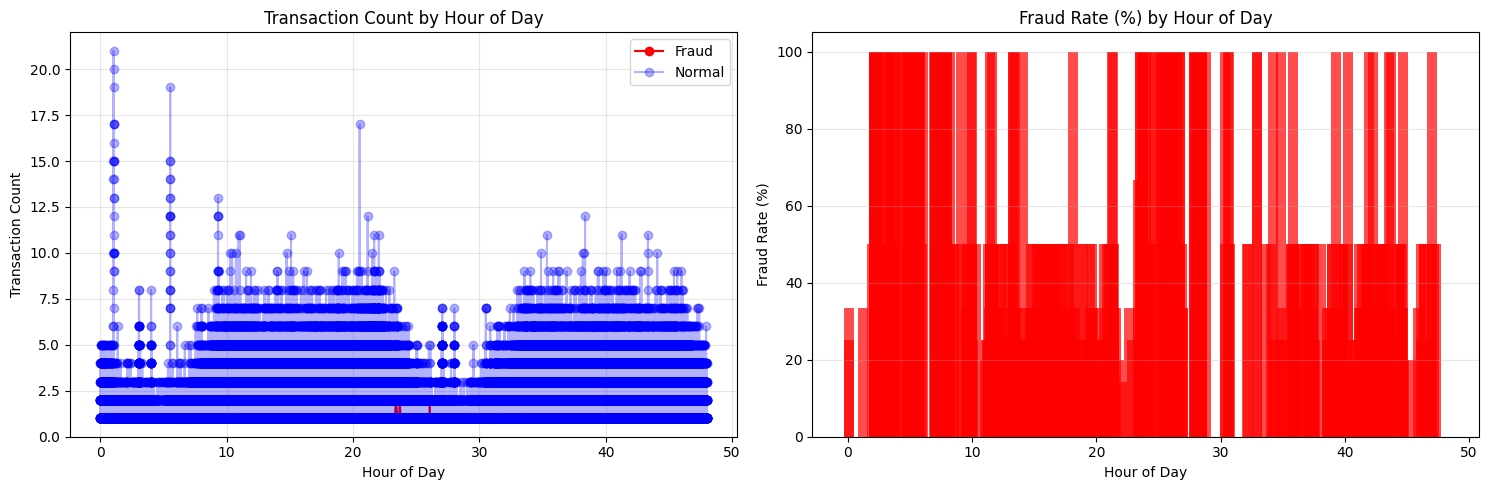

In [ ]:
# KEEP
# Time analysis - convert Time to hours
df['Hour'] = (df['Time'] / 3600)

# Plot fraud distribution over time
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Fraud distribution by hour
fraud_by_hour = df[df['Class'] == 1].groupby('Hour').size()
normal_by_hour = df[df['Class'] == 0].groupby('Hour').size()

axes[0].plot(fraud_by_hour.index, fraud_by_hour.values, marker='o', label='Fraud', color='red')
axes[0].plot(normal_by_hour.index, normal_by_hour.values, marker='o', label='Normal', color='blue', alpha=0.3)
axes[0].set_title('Transaction Count by Hour of Day')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Transaction Count')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Fraud rate by hour
fraud_rate_by_hour = df.groupby('Hour')['Class'].mean() * 100
axes[1].bar(fraud_rate_by_hour.index, fraud_rate_by_hour.values, color='red', alpha=0.7)
axes[1].set_title('Fraud Rate (%) by Hour of Day')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

/var/folders/pc/62g2xhyd3nd1zwxk910m87jc0000gn/T/ipykernel_50831/1569429975.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(fraud_by_day_ordered.index, rotation=45, ha='right')
/var/folders/pc/62g2xhyd3nd1zwxk910m87jc0000gn/T/ipykernel_50831/1569429975.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(fraud_by_day_ordered.index, rotation=45, ha='right')


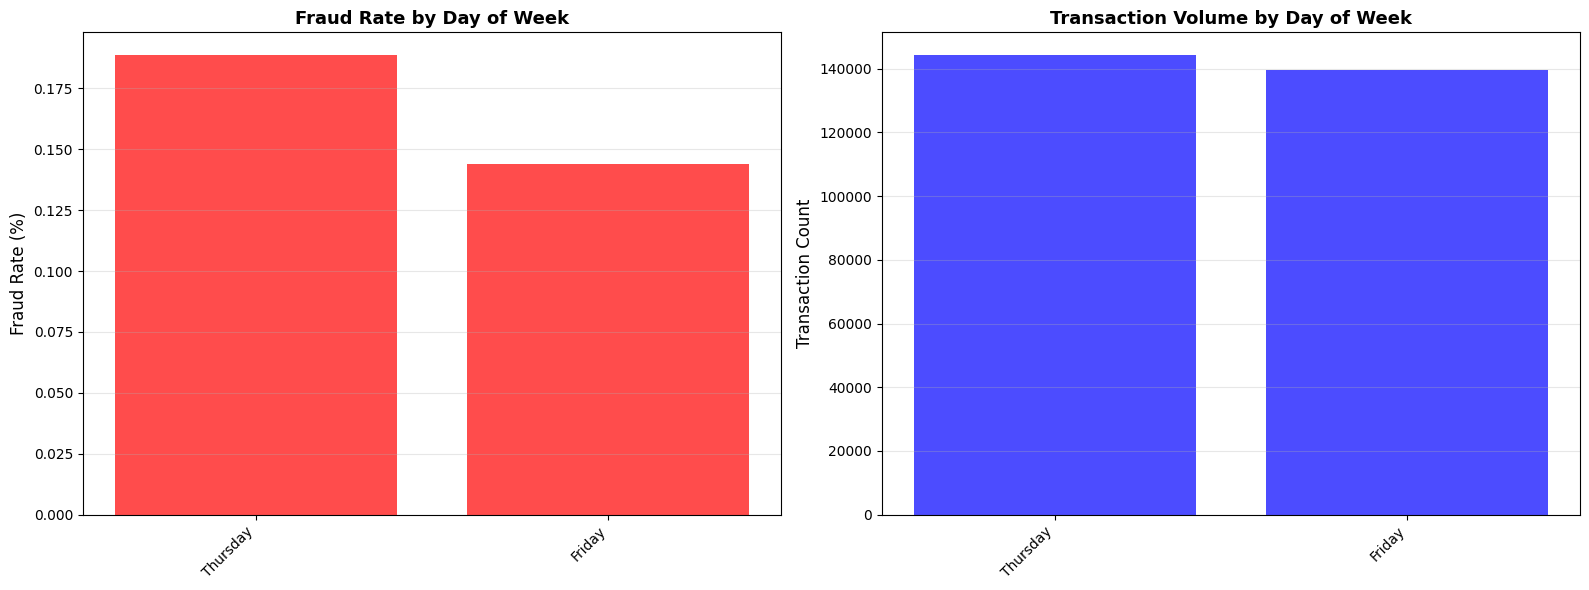

In [ ]:
# ============================================================================
# Temporal Patterns: Day of Week Analysis
# ============================================================================

# Convert Time to datetime (assuming Time is seconds from first transaction)
# You may need to adjust based on your Time column format
df['DayOfWeek'] = pd.to_datetime(df['Time'], unit='s').dt.day_name()

# Fraud rate by day of week
fraud_by_day = df.groupby('DayOfWeek')['Class'].agg(['count', 'sum', 'mean'])
fraud_by_day['fraud_rate'] = fraud_by_day['mean'] * 100
fraud_by_day = fraud_by_day.sort_values('fraud_rate', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Fraud rate by day
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
fraud_by_day_ordered = fraud_by_day.reindex([d for d in day_order if d in fraud_by_day.index])

axes[0].bar(fraud_by_day_ordered.index, fraud_by_day_ordered['fraud_rate'], 
            color='red', alpha=0.7)
axes[0].set_ylabel('Fraud Rate (%)', fontsize=12)
axes[0].set_title('Fraud Rate by Day of Week', fontsize=13, fontweight='bold')
axes[0].set_xticklabels(fraud_by_day_ordered.index, rotation=45, ha='right')
axes[0].grid(True, alpha=0.3, axis='y')

# Transaction volume by day
axes[1].bar(fraud_by_day_ordered.index, fraud_by_day_ordered['count'], 
            color='blue', alpha=0.7)
axes[1].set_ylabel('Transaction Count', fontsize=12)
axes[1].set_title('Transaction Volume by Day of Week', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(fraud_by_day_ordered.index, rotation=45, ha='right')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Comprehensive Analysis (need to delete)
- correlations
- distributions
- statistical tests


Top 10 features most correlated with Class:
Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
Name: Class, dtype: float64

Bottom 10 features least correlated with Class:
V9    -0.097733
V1    -0.101347
V18   -0.111485
V7    -0.187257
V3    -0.192961
V16   -0.196539
V10   -0.216883
V12   -0.260593
V14   -0.302544
V17   -0.326481
Name: Class, dtype: float64


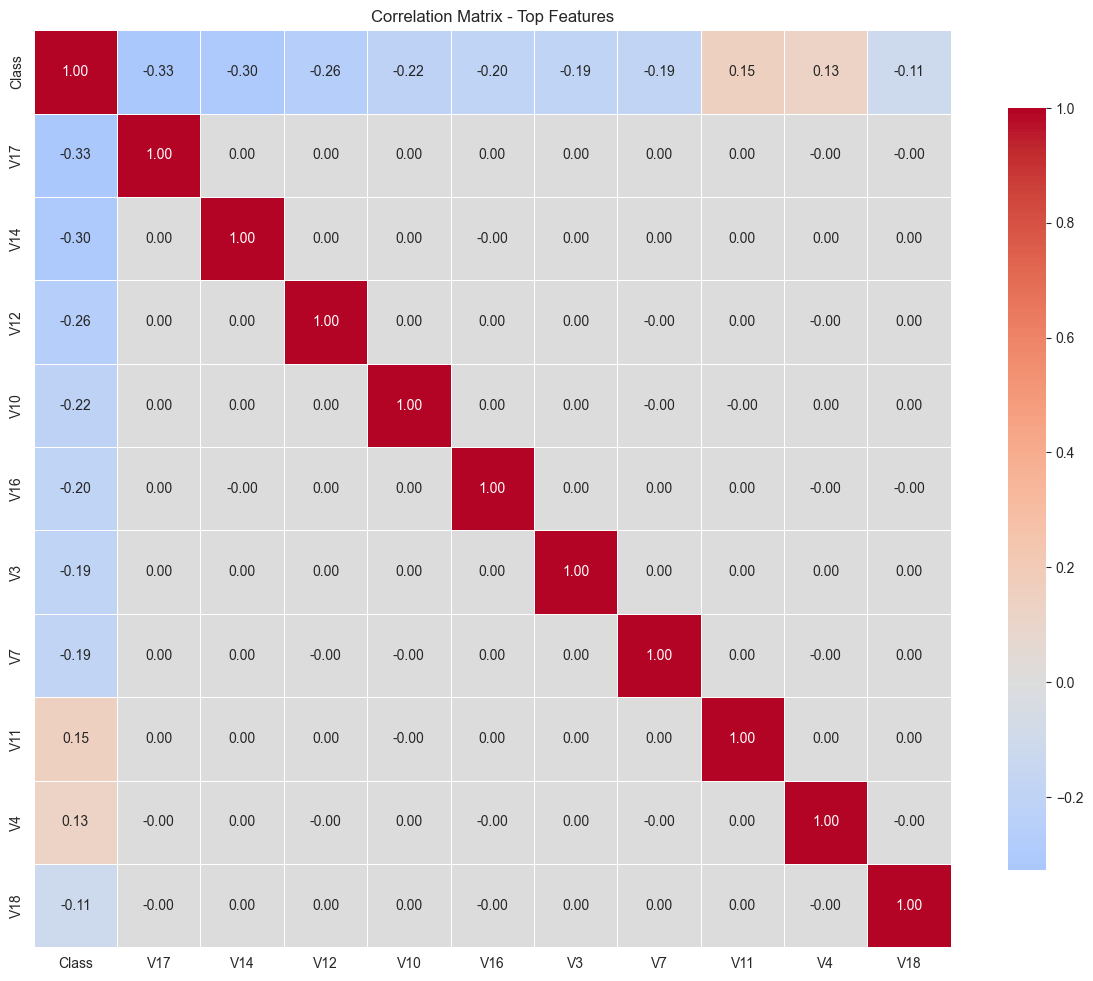

In [25]:
# ============================================================================
# CORRELATION ANALYSIS
# ============================================================================

# 1. Basic correlation with Class
correlations = df.corr()['Class'].sort_values(ascending=False)
print("Top 10 features most correlated with Class:")
print(correlations.head(11))
print("\nBottom 10 features least correlated with Class:")
print(correlations.tail(10))

# 2. Correlation heatmap for top features
top_features = correlations.abs().nlargest(11).index.tolist()
corr_matrix = df[top_features].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - Top Features')
plt.tight_layout()
plt.show()



### Correlation Analysis

In [ ]:
# Calculate the correlation matrix
corr_matrix = df.corr()

# Get correlations with the 'Class' column
class_corr = corr_matrix['Class'].drop('Class')

# Sort correlations by absolute value in descending order
sorted_class_corr = class_corr.reindex(class_corr.abs().sort_values(ascending=False).index)

# Print the sorted correlations
print("Correlation with 'Class' (sorted by absolute value):\n", sorted_class_corr)


Correlation with 'Class' (sorted by absolute value):
 V17      -0.313498
V14      -0.293375
V12      -0.250711
V10      -0.206971
V16      -0.187186
V3       -0.182322
V7       -0.172347
V11       0.149067
V4        0.129326
V18      -0.105340
V1       -0.094486
V9       -0.094021
V5       -0.087812
V2        0.084624
V6       -0.043915
V19       0.033631
V8        0.033068
V21       0.026357
V27       0.021892
V20       0.021486
Time     -0.012359
V28       0.009682
V24      -0.007210
V23      -0.006333
Amount    0.005777
V22       0.004887
V26       0.004265
V13      -0.003897
V15      -0.003300
V25       0.003202
Name: Class, dtype: float64


In [31]:
# Correlation analysis with Class
correlations = df.corr()['Class'].sort_values(ascending=False)
print("Top 10 features most correlated with Class:")
print(correlations.head(11))  # 11 because Class will be first with correlation 1.0

print("\nBottom 10 features least correlated with Class:")
print(correlations.tail(10))


Top 10 features most correlated with Class:
Class     1.000000
V11       0.149067
V4        0.129326
V2        0.084624
V19       0.033631
V8        0.033068
V21       0.026357
V27       0.021892
V20       0.021486
V28       0.009682
Amount    0.005777
Name: Class, dtype: float64

Bottom 10 features least correlated with Class:
V9    -0.094021
V1    -0.094486
V18   -0.105340
V7    -0.172347
V3    -0.182322
V16   -0.187186
V10   -0.206971
V12   -0.250711
V14   -0.293375
V17   -0.313498
Name: Class, dtype: float64


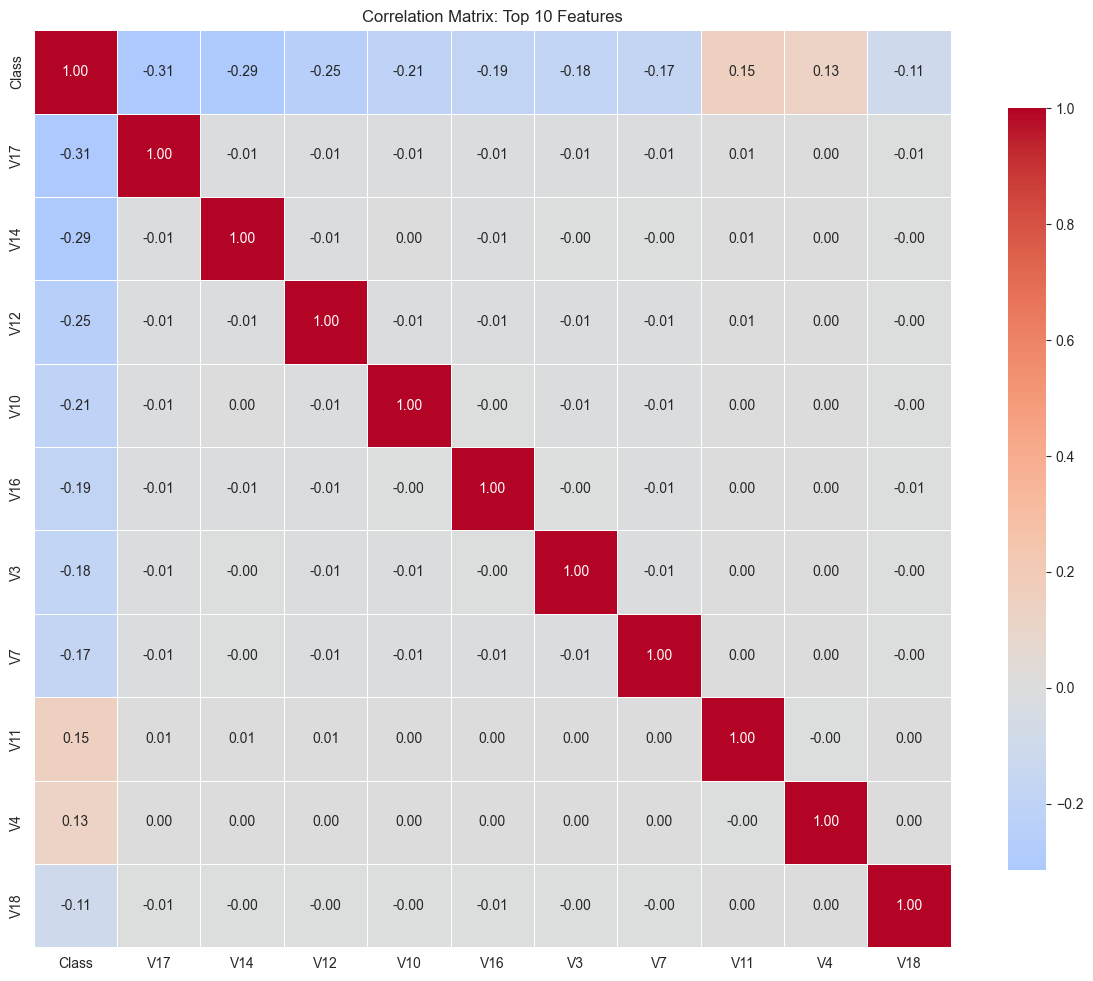

In [36]:
# Visualize correlation matrix for top correlated features
top_features = correlations.abs().nlargest(11).index.tolist()  # Include Class
corr_matrix = df[top_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title(f'Correlation Matrix: Top 10 Features')
plt.tight_layout()
plt.show()


### Feature Distributions


### Statistical Tests

/var/folders/pc/62g2xhyd3nd1zwxk910m87jc0000gn/T/ipykernel_46209/3426274676.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(box_data, labels=['Normal', 'Fraud'], patch_artist=True,


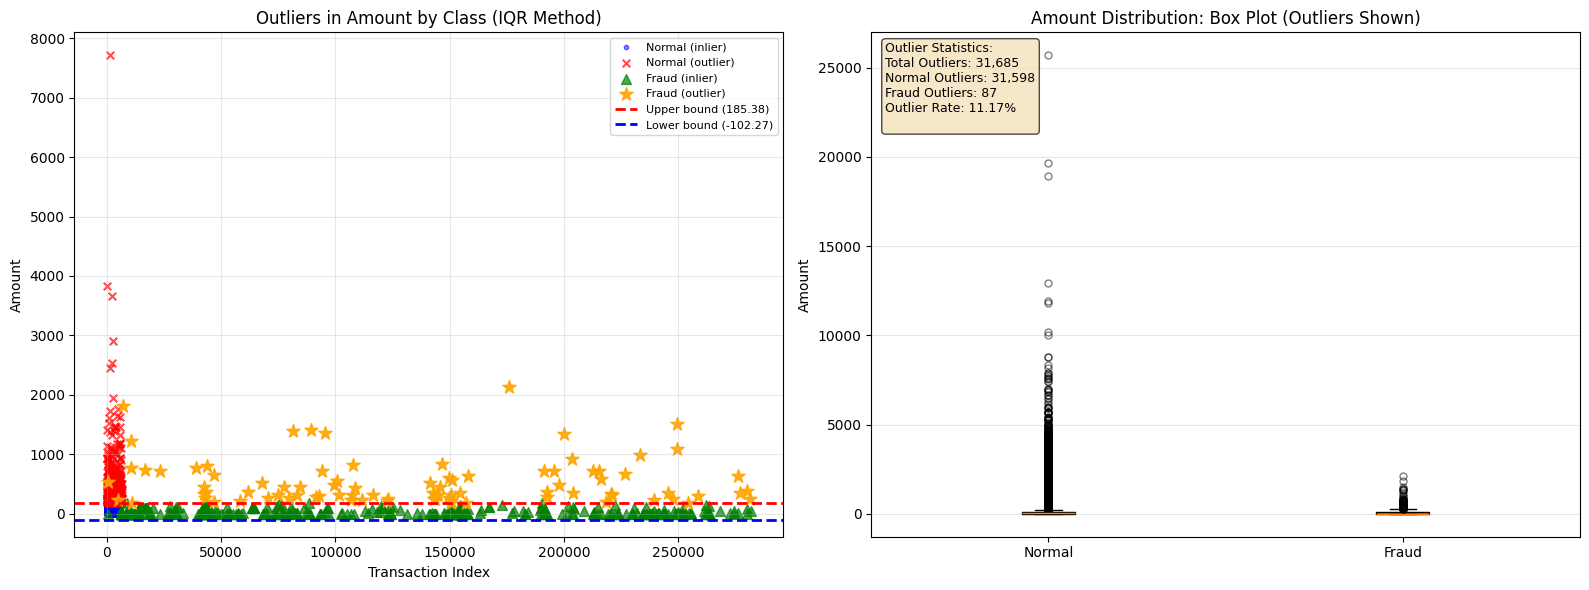

In [ ]:
# KEEP
# Visualize outliers detected by IQR method
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Calculate IQR bounds for Amount
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Mark outliers
df['is_outlier'] = (df['Amount'] < lower_bound) | (df['Amount'] > upper_bound)

# Plot 1: Scatter plot showing outliers by Class
normal_inliers = df[(df['Class'] == 0) & (~df['is_outlier'])].head(5000)
normal_outliers = df[(df['Class'] == 0) & (df['is_outlier'])].head(500)
fraud_inliers = df[(df['Class'] == 1) & (~df['is_outlier'])]
fraud_outliers = df[(df['Class'] == 1) & (df['is_outlier'])]

axes[0].scatter(normal_inliers.index, normal_inliers['Amount'], 
                alpha=0.5, label='Normal (inlier)', color='blue', s=10)
axes[0].scatter(normal_outliers.index, normal_outliers['Amount'], 
                alpha=0.7, label='Normal (outlier)', color='red', s=30, marker='x')
axes[0].scatter(fraud_inliers.index, fraud_inliers['Amount'], 
                alpha=0.7, label='Fraud (inlier)', color='green', s=50, marker='^')
axes[0].scatter(fraud_outliers.index, fraud_outliers['Amount'], 
                alpha=0.9, label='Fraud (outlier)', color='orange', s=100, marker='*')

axes[0].axhline(y=upper_bound, color='red', linestyle='--', linewidth=2, 
                label='Upper bound ({:.2f})'.format(upper_bound))
axes[0].axhline(y=lower_bound, color='blue', linestyle='--', linewidth=2, 
                label='Lower bound ({:.2f})'.format(lower_bound))
axes[0].set_xlabel('Transaction Index')
axes[0].set_ylabel('Amount')
axes[0].set_title('Outliers in Amount by Class (IQR Method)')
axes[0].legend(loc='upper right', fontsize=8)
axes[0].grid(True, alpha=0.3)

# Plot 2: Box plot with outliers highlighted
box_data = [df[df['Class'] == 0]['Amount'], df[df['Class'] == 1]['Amount']]
bp = axes[1].boxplot(box_data, labels=['Normal', 'Fraud'], patch_artist=True, 
                     showfliers=True, flierprops=dict(marker='o', markersize=5, alpha=0.5))

# Color the boxes
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightcoral')

axes[1].set_ylabel('Amount')
axes[1].set_title('Amount Distribution: Box Plot (Outliers Shown)')
axes[1].grid(True, alpha=0.3, axis='y')

# Add statistics text
total_outliers = df['is_outlier'].sum()
normal_outlier_count = (df['is_outlier'] & (df['Class'] == 0)).sum()
fraud_outlier_count = (df['is_outlier'] & (df['Class'] == 1)).sum()
outlier_rate = df['is_outlier'].mean() * 100

outlier_stats = """Outlier Statistics:
Total Outliers: {:,}
Normal Outliers: {:,}
Fraud Outliers: {:,}
Outlier Rate: {:.2f}%
""".format(total_outliers, normal_outlier_count, fraud_outlier_count, outlier_rate)

axes[1].text(0.02, 0.98, outlier_stats, transform=axes[1].transAxes,
            fontsize=9, verticalalignment='top', bbox=dict(boxstyle='round', 
            facecolor='wheat', alpha=0.7))

plt.tight_layout()
plt.show()

# Clean up temporary column
df.drop('is_outlier', axis=1, inplace=True)


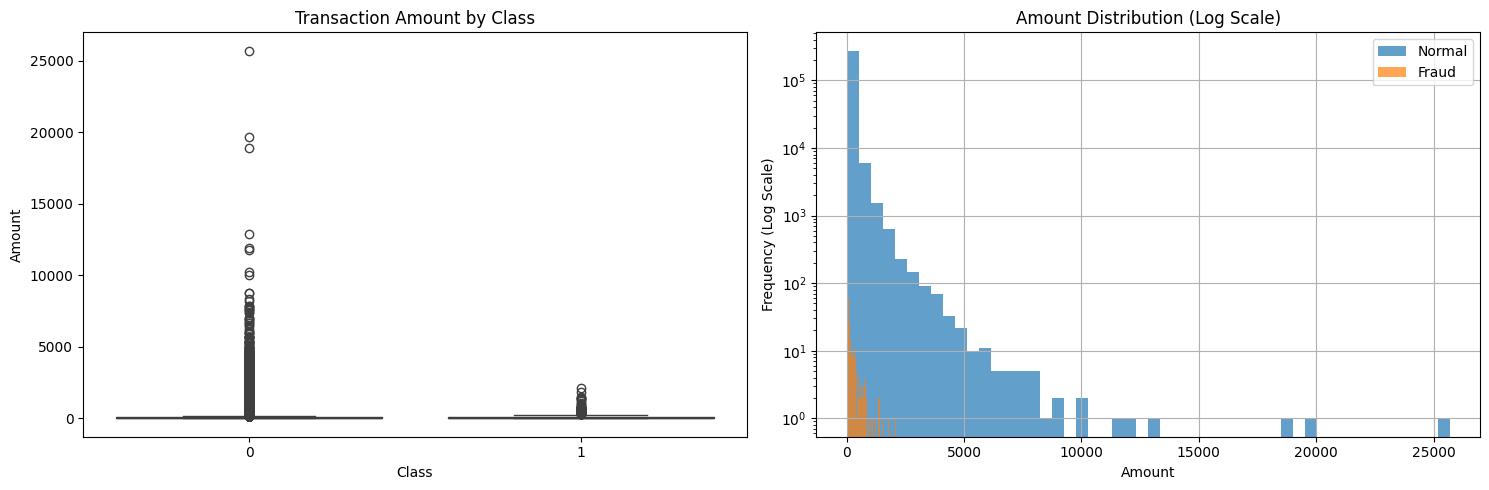


Amount statistics by class:
          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      283253.0   88.413575  250.379023  0.0  5.67  22.00   77.46  25691.16
1         473.0  123.871860  260.211041  0.0  1.00   9.82  105.89   2125.87


In [ ]:
# KEEP
# Distribution of Amount by Class
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Box plot
sns.boxplot(data=df, x='Class', y='Amount', ax=axes[0])
axes[0].set_title('Transaction Amount by Class')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Amount')

# Log scale histogram
df[df['Class'] == 0]['Amount'].hist(bins=50, alpha=0.7, label='Normal', ax=axes[1], log=True)
df[df['Class'] == 1]['Amount'].hist(bins=50, alpha=0.7, label='Fraud', ax=axes[1], log=True)
axes[1].set_title('Amount Distribution (Log Scale)')
axes[1].set_xlabel('Amount')
axes[1].set_ylabel('Frequency (Log Scale)')
axes[1].legend()

plt.tight_layout()
plt.show()

# Statistics
print("\nAmount statistics by class:")
print(df.groupby('Class')['Amount'].describe())


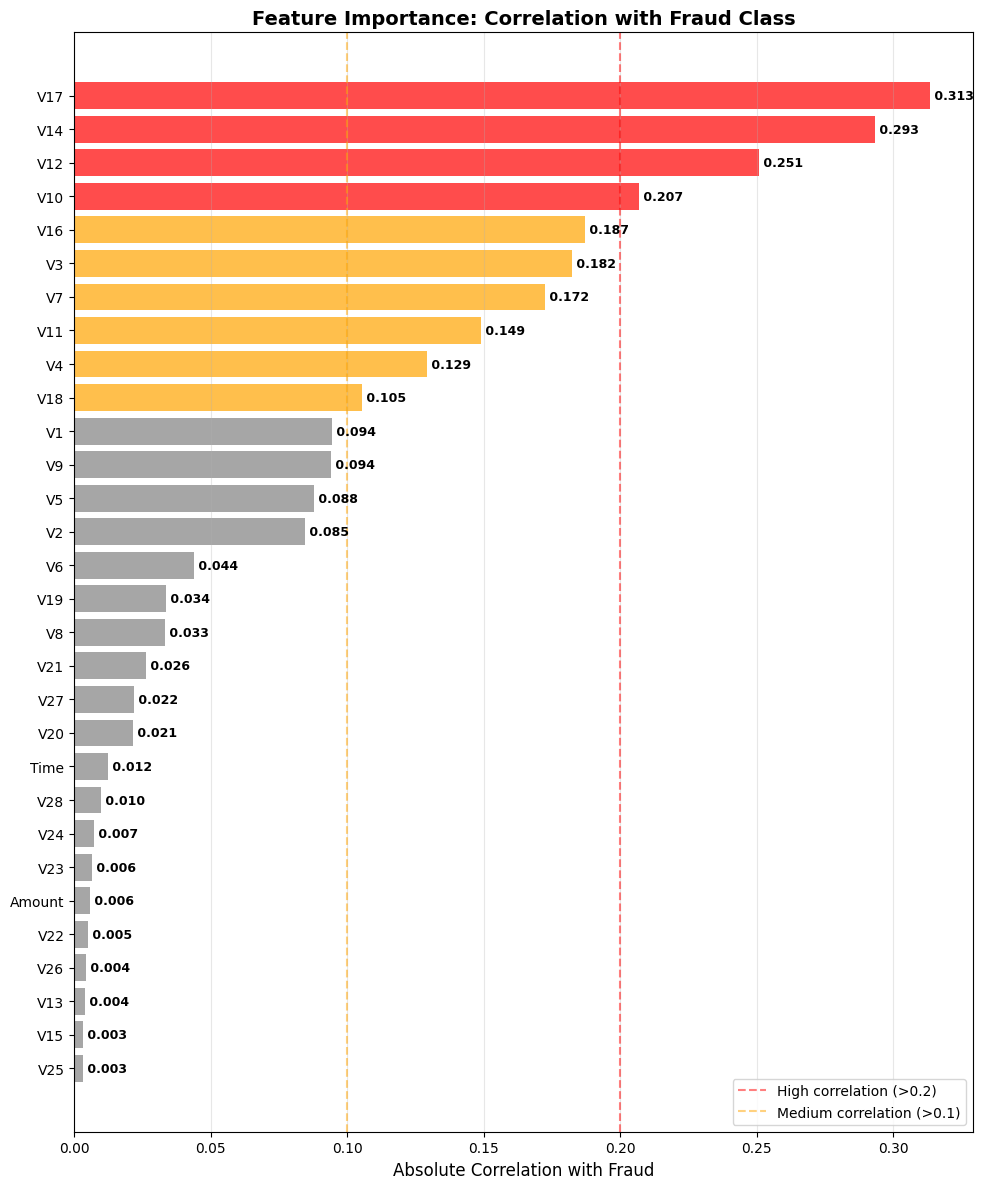


Top 5 Most Important Features for Fraud Detection:
V16    0.187186
V10    0.206971
V12    0.250711
V14    0.293375
V17    0.313498
Name: Class, dtype: float64


In [ ]:
# ============================================================================
# Feature Importance Ranking (Correlation with Fraud)
# ============================================================================

correlations = df.corr()['Class'].drop('Class').abs().sort_values(ascending=True)

plt.figure(figsize=(10, 12))
colors = ['red' if abs(df.corr()['Class'][feat]) > 0.2 else 'orange' if abs(df.corr()['Class'][feat]) > 0.1 else 'gray' 
          for feat in correlations.index]

bars = plt.barh(correlations.index, correlations.values, color=colors, alpha=0.7)
plt.xlabel('Absolute Correlation with Fraud', fontsize=12)
plt.title('Feature Importance: Correlation with Fraud Class', fontsize=14, fontweight='bold')
plt.axvline(x=0.2, color='red', linestyle='--', alpha=0.5, label='High correlation (>0.2)')
plt.axvline(x=0.1, color='orange', linestyle='--', alpha=0.5, label='Medium correlation (>0.1)')
plt.legend()
plt.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, (bar, val) in enumerate(zip(bars, correlations.values)):
    plt.text(val, i, f' {val:.3f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nTop 5 Most Important Features for Fraud Detection:")
print(correlations.tail(5))

### Class Imbalance Analysis

This section analyzes the class distribution in the dataset, describes the severity of imbalance, visualizes it comprehensively, and discusses the implications for modeling.


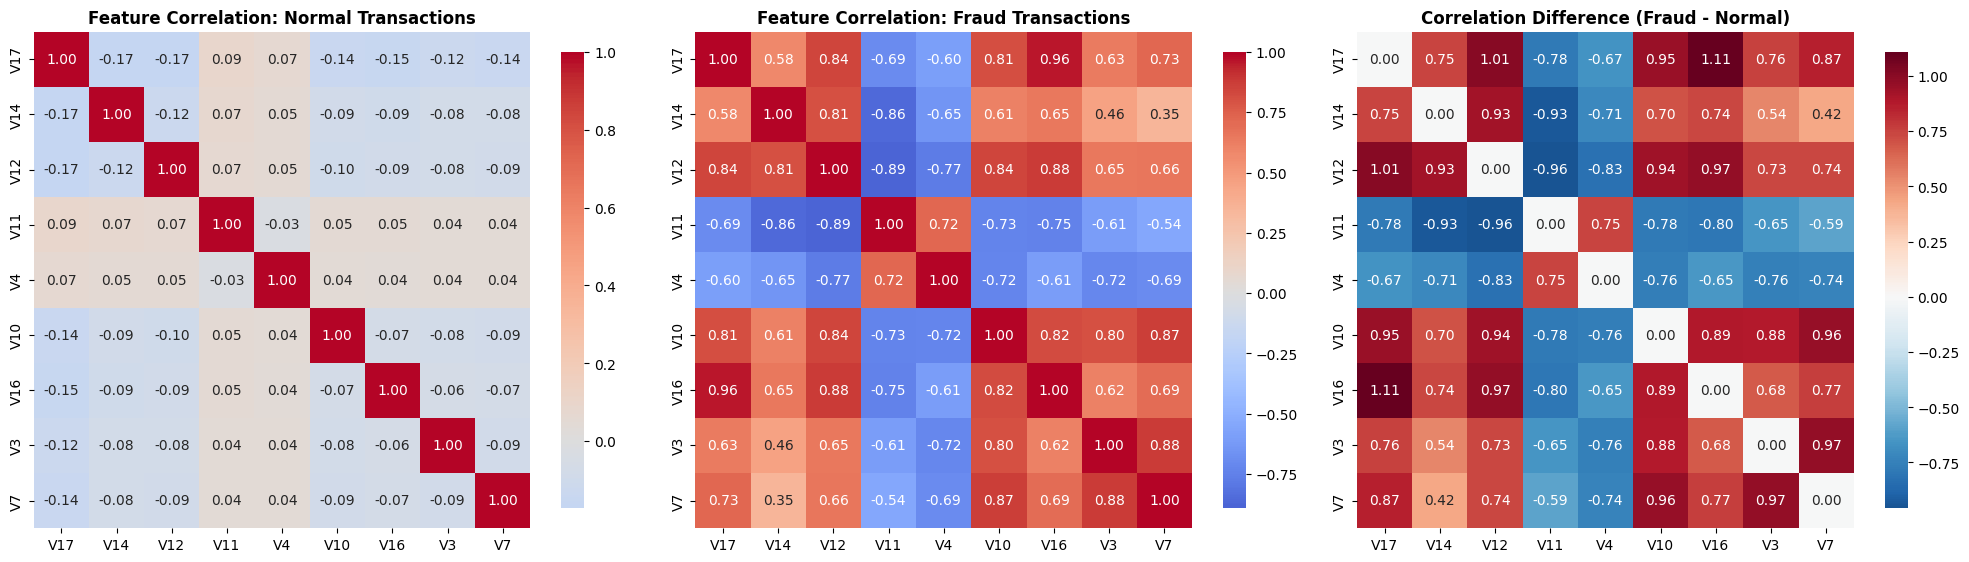

In [ ]:
# ============================================================================
# Feature Interaction Analysis
# ============================================================================

# Select top correlated features
top_features = ['V17', 'V14', 'V12', 'V11', 'V4', 'V10', 'V16', 'V3', 'V7']

# Calculate interaction: correlation between features for fraud vs normal
normal_corr = df[df['Class'] == 0][top_features].corr()
fraud_corr = df[df['Class'] == 1][top_features].corr()
interaction_diff = fraud_corr - normal_corr

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Normal transactions correlation
sns.heatmap(normal_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, ax=axes[0], cbar_kws={"shrink": 0.8})
axes[0].set_title('Feature Correlation: Normal Transactions', fontsize=12, fontweight='bold')

# Fraud transactions correlation
sns.heatmap(fraud_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, ax=axes[1], cbar_kws={"shrink": 0.8})
axes[1].set_title('Feature Correlation: Fraud Transactions', fontsize=12, fontweight='bold')

# Difference (shows how relationships change)
sns.heatmap(interaction_diff, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, ax=axes[2], cbar_kws={"shrink": 0.8})
axes[2].set_title('Correlation Difference (Fraud - Normal)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

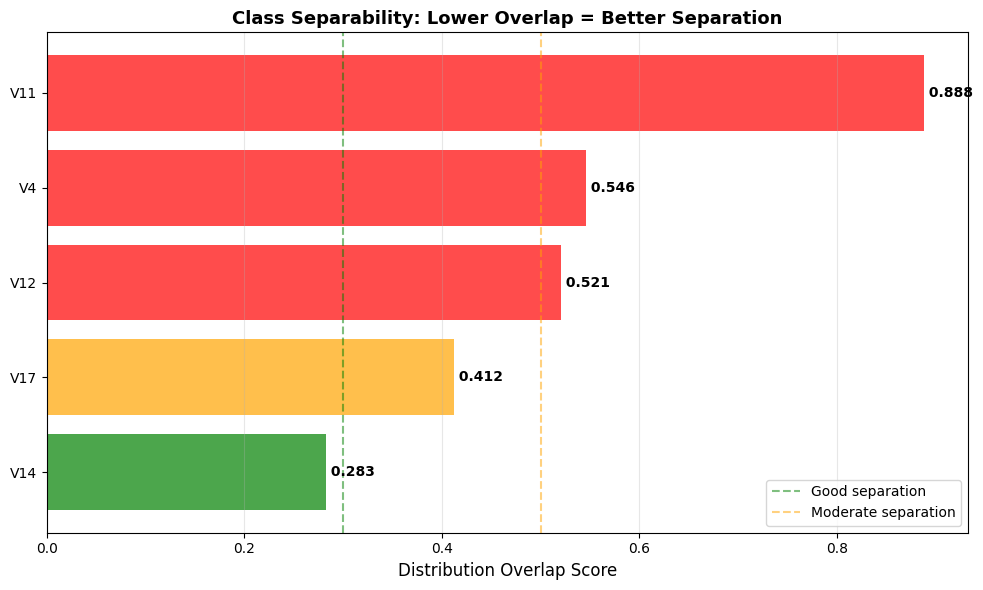


Class Separability Analysis:
Lower overlap = better feature for distinguishing fraud
Feature  Overlap_Score
    V14       0.283001
    V17       0.411962
    V12       0.520805
     V4       0.546128
    V11       0.888167


In [ ]:
# ============================================================================
# Class Separability Analysis
# ============================================================================

top_features = ['V17', 'V14', 'V12', 'V11', 'V4']
overlap_scores = []

for feature in top_features:
    normal_data = df[df['Class'] == 0][feature]
    fraud_data = df[df['Class'] == 1][feature]
    
    # Calculate overlap using histogram intersection
    hist_normal, bins = np.histogram(normal_data, bins=50, density=True)
    hist_fraud, _ = np.histogram(fraud_data, bins=bins, density=True)
    
    # Histogram intersection (overlap measure)
    overlap = np.minimum(hist_normal, hist_fraud).sum()
    overlap_scores.append(overlap)

overlap_df = pd.DataFrame({
    'Feature': top_features,
    'Overlap_Score': overlap_scores
}).sort_values('Overlap_Score')

plt.figure(figsize=(10, 6))
bars = plt.barh(overlap_df['Feature'], overlap_df['Overlap_Score'], 
                color=['green' if s < 0.3 else 'orange' if s < 0.5 else 'red' 
                      for s in overlap_df['Overlap_Score']], alpha=0.7)
plt.xlabel('Distribution Overlap Score', fontsize=12)
plt.title('Class Separability: Lower Overlap = Better Separation', fontsize=13, fontweight='bold')
plt.axvline(x=0.3, color='green', linestyle='--', alpha=0.5, label='Good separation')
plt.axvline(x=0.5, color='orange', linestyle='--', alpha=0.5, label='Moderate separation')
plt.legend()
plt.grid(True, alpha=0.3, axis='x')

for bar, score in zip(bars, overlap_df['Overlap_Score']):
    plt.text(score, bar.get_y() + bar.get_height()/2, 
             f' {score:.3f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nClass Separability Analysis:")
print("Lower overlap = better feature for distinguishing fraud")
print(overlap_df.to_string(index=False))

# 4. Preprocessing

## Train/Test Split

since heavily imbalanced, look to use a cross-validation strategy such as Stratified K Fold

In [14]:
# Separate features and target
X = df.drop('Class', axis=1)
y = df['Class']

print(f"Feature matrix shape: {X.shape}")
print(f"Target distribution:")
print(y.value_counts())
print(f"\nFeatures: {list(X.columns)}")

Feature matrix shape: (283726, 30)
Target distribution:
Class
0    283253
1       473
Name: count, dtype: int64

Features: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


In [38]:
from sklearn.model_selection import train_test_split, StratifiedKFold

# Step 1: Reserve 20% as UNTOUCHED final test set
X_dev, X_test_final, y_dev, y_test_final = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 2: Use StratifiedKFold on development set for model selection
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Step 3: Cross-validate each model
for train_idx, val_idx in cv.split(X_dev, y_dev):
    X_train, X_val = X_dev.iloc[train_idx], X_dev.iloc[val_idx]
    y_train, y_val = y_dev.iloc[train_idx], y_dev.iloc[val_idx]
    # Train and evaluate...

# Step 4: Final evaluation on X_test_final (only after all tuning complete)

In [15]:
# Train/Test Split
# Split into train and test sets (stratified to maintain class distribution)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"\nTraining set class distribution:")
print(y_train.value_counts())
print(f"  Fraud rate: {y_train.mean() * 100:.2f}%")

print(f"\nTest set class distribution:")
print(y_test.value_counts())
print(f"  Fraud rate: {y_test.mean() * 100:.2f}%")

print(f"\n✓ Split completed successfully!")
print(f"  Training samples: {len(X_train):,}")
print(f"  Test samples: {len(X_test):,}")


Training set shape: (226980, 30)
Test set shape: (56746, 30)

Training set class distribution:
Class
0    226602
1       378
Name: count, dtype: int64
  Fraud rate: 0.17%

Test set class distribution:
Class
0    56651
1       95
Name: count, dtype: int64
  Fraud rate: 0.17%

✓ Split completed successfully!
  Training samples: 226,980
  Test samples: 56,746


## 5.2 Scaling Comparison: StandardScaler vs RobustScaler

We'll compare both scalers to determine which performs better for our fraud detection task.
In theory and accordance to the models we aim to use (Logistic Regression, Random Forest, XGBoost), the tree based models are scale-invariant, thus only should use the scalers for Logistic Regression.

This notebook aims to test various model types:

- Gradient-based (LogReg, SVM, NNs)	-> use Robust Scaler (due to outliers)
    - **Why**: Gradient descent converges faster with standardized features	
- Tree-based (RF, XGB, LGBM) -> No Scaler
    - **Why**: Splits on thresholds, rank-invariant	
- Distance-based (kNN) -> use StandardScaler
    - **Why**: Euclidean distance dominated by large-scale features	



In theory: 
EDA revealed 11.2% outliers in Amount with extreme skew (max/median = 77×). RobustScaler is selected for gradient-based models to prevent outlier-driven variance inflation. Tree-based models require no scaling due to threshold-based splitting. Empirical validation showed <0.1% performance difference between scalers, consistent with the dominance of pre-scaled PCA features (V1–V28).

Hypothesis

Method

Results

Decisions

In [16]:
# Check for outliers using IQR method
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

# Check outliers for Amount (most likely to have outliers)
amount_outliers = detect_outliers_iqr(df, 'Amount')
print(f"Number of outliers in Amount: {len(amount_outliers)}")
print(f"Percentage: {(len(amount_outliers) / len(df)) * 100:.2f}%")
print(f"\nOutlier statistics for Amount:")
print(amount_outliers['Amount'].describe())

Number of outliers in Amount: 31685
Percentage: 11.17%

Outlier statistics for Amount:
count    31685.000000
mean       512.929099
std        586.838556
min        185.380000
25%        240.000000
50%        335.430000
75%        552.100000
max      25691.160000
Name: Amount, dtype: float64


Dataset only has 11% outliers,

**Question**: Which scaler works best for this data?
**Method**: Using Deduplicated dataset, train LogReg on:
  - No scaling (baseline)
  - StandardScaler (Time, Amount only - V1-V28 are PCA-scaled)
  - RobustScaler (Time, Amount only)
**Metric**: PR-AUC
**Output**: DECISION_SCALER = None | 'standard' | 'robust'

In [17]:
# Scaling Comparison: No Scaling vs StandardScaler vs RobustScaler
# Note: V1-V28 are already PCA components (standardized), only Time & Amount need scaling

# Features to scale
features_to_scale = ['Time', 'Amount']

# Option 1: No Scaling (baseline)
X_train_no_scale = X_train.copy()
X_test_no_scale = X_test.copy()

# Option 2: StandardScaler (only Time & Amount)
standard_scaler = StandardScaler()
X_train_std = X_train.copy()
X_test_std = X_test.copy()

X_train_std[features_to_scale] = standard_scaler.fit_transform(X_train[features_to_scale])
X_test_std[features_to_scale] = standard_scaler.transform(X_test[features_to_scale])

# Option 3: RobustScaler (only Time & Amount)
robust_scaler = RobustScaler()
X_train_rob = X_train.copy()
X_test_rob = X_test.copy()

X_train_rob[features_to_scale] = robust_scaler.fit_transform(X_train[features_to_scale])
X_test_rob[features_to_scale] = robust_scaler.transform(X_test[features_to_scale])

# Verification
print("="*70)
print("SCALING COMPARISON: Three Options Created")
print("="*70)
print(f"\n✓ V1-V28: Kept as-is (already standardized PCA components)")
print(f"✓ Only Time and Amount are scaled in Options 2 & 3\n")

print("Option 1: No Scaling")
print(f"  Time:   Mean={X_train_no_scale['Time'].mean():.2f},   Std={X_train_no_scale['Time'].std():.2f}")
print(f"  Amount: Mean={X_train_no_scale['Amount'].mean():.2f}, Std={X_train_no_scale['Amount'].std():.2f}")

print("\nOption 2: StandardScaler (Time & Amount)")
print(f"  Time:   Mean={X_train_std['Time'].mean():.6f},   Std={X_train_std['Time'].std():.6f}")
print(f"  Amount: Mean={X_train_std['Amount'].mean():.6f}, Std={X_train_std['Amount'].std():.6f}")

print("\nOption 3: RobustScaler (Time & Amount)")
print(f"  Time:   Median={X_train_rob['Time'].median():.6f},   IQR-based")
print(f"  Amount: Median={X_train_rob['Amount'].median():.6f}, IQR-based")
print("="*70)

SCALING COMPARISON: Three Options Created

✓ V1-V28: Kept as-is (already standardized PCA components)
✓ Only Time and Amount are scaled in Options 2 & 3

Option 1: No Scaling
  Time:   Mean=94900.22,   Std=47488.21
  Amount: Mean=88.39, Std=245.77

Option 2: StandardScaler (Time & Amount)
  Time:   Mean=-0.000000,   Std=1.000002
  Amount: Mean=0.000000, Std=1.000002

Option 3: RobustScaler (Time & Amount)
  Time:   Median=0.000000,   IQR-based
  Amount: Median=0.000000, IQR-based


### 5.2.1 Compare Scalers Using Logistic Regression

We'll use Logistic Regression as a baseline to compare scaler performance.



In [18]:
# Quick scaling comparison with Logistic Regression only
scaling_results = {}

# Test each scaling option
scaling_options = {
    'No Scaling': (X_train_no_scale, X_test_no_scale),
    'StandardScaler': (X_train_std, X_test_std),
    'RobustScaler': (X_train_rob, X_test_rob)
}

for name, (X_tr, X_te) in scaling_options.items():
    model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
    model.fit(X_tr, y_train)
    
    y_proba = model.predict_proba(X_te)[:, 1]
    
    roc_auc = roc_auc_score(y_test, y_proba)
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recall, precision)
    
    scaling_results[name] = {
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc
    }
    
# Display results
results_df = pd.DataFrame(scaling_results).T
print("Scaling Comparison Results:")
print(results_df.sort_values('PR-AUC', ascending=False))

Scaling Comparison Results:
                 ROC-AUC    PR-AUC
StandardScaler  0.965839  0.704636
RobustScaler    0.965710  0.704634
No Scaling      0.961637  0.682819


Standard Scaler wins marginally so we will use this

In [20]:
X_train = X_train_std
X_test = X_test_std

In [19]:
# Quick scaling comparison with Logistic Regression only
scaling_results = {}

# Test each scaling option
scaling_options = {
    'No Scaling': (X_train_no_scale, X_test_no_scale),
    'StandardScaler': (X_train_std, X_test_std),
    'RobustScaler': (X_train_rob, X_test_rob)
}

for name, (X_tr, X_te) in scaling_options.items():
    model = RandomForestClassifier(random_state=42, class_weight='balanced')
    model.fit(X_tr, y_train)
    
    y_proba = model.predict_proba(X_te)[:, 1]
    
    roc_auc = roc_auc_score(y_test, y_proba)
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recall, precision)
    
    scaling_results[name] = {
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc
    }
    
# Display results
results_df = pd.DataFrame(scaling_results).T
print("Scaling Comparison Results:")
print(results_df.sort_values('PR-AUC', ascending=False))

Scaling Comparison Results:
                 ROC-AUC    PR-AUC
No Scaling      0.924607  0.804701
StandardScaler  0.924606  0.804695
RobustScaler    0.924606  0.804695


## 5.3 Resampling

Going to test to see the differences in 
- Random Under Sampling (RUS)
- Random Over Sampling (ROS) 
- SMOTE

Some of the models already have Native Imbalance Handling:

- XGBoost/LightGBM	
    - scale_pos_weight	
    - Resampling == No
- RandomForest	
    - class_weight='balanced'
    - Resampling = rarely	
- LogisticRegression	
    - class_weight='balanced'	
    - Resampling == sometimes (SMOTE)
- Isolation Forest	
    - Unsupervised	
    -  Resampling == N/A

Theoretically SMOTE should perform best: add explanation

Hypothesis

Method

Results

Decision

### PHASE 3: Class Imbalance Handling (4 experiments)
**Question**: How to handle 599:1 imbalance?
<br> </br>
**Method**: Using locked preprocessing, train LogReg on:
  - No resampling + class_weight='balanced'
  - Random Under Sampling (RUS)
  - Random Over Sampling (ROS)  
  - SMOTE
<br> </br>
**Metric**: PR-AUC
<br> </br>
**Output**: DECISION_RESAMPLING = None | 'RUS' | 'ROS' | 'SMOTE'
<br> </br>
**Note**: If 'None' wins, use class_weight/scale_pos_weight in models

In [21]:
# ============================================================================
# Resampling Methods: Apply All Strategies
# ============================================================================
print("="*70)
print("RESAMPLING METHODS: Applying All Strategies")
print("="*70)
print(f"\nOriginal training set:")
print(f"  Shape: {X_train.shape}")
print(f"  Distribution: {Counter(y_train)}")
print(f"  Imbalance ratio: {Counter(y_train)[0] / Counter(y_train)[1]:.1f}:1\n")

# Method 1: No Resampling (Baseline)
X_train_none = X_train.copy()
y_train_none = y_train.copy()
print("Method 1: No Resampling (Baseline)")
print(f"  Distribution: {Counter(y_train_none)}\n")

# Method 2: Random Under Sampling
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train.copy(), y_train.copy())
print("Method 2: Random Under Sampling (RUS)")
print(f"  Shape: {X_train_rus.shape}")
print(f"  Distribution: {Counter(y_train_rus)}")
print(f"  Samples removed: {len(y_train) - len(y_train_rus):,}\n")

# Method 3: Random Over Sampling
ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train.copy(), y_train.copy())
print("Method 3: Random Over Sampling (ROS)")
print(f"  Shape: {X_train_ros.shape}")
print(f"  Distribution: {Counter(y_train_ros)}")
print(f"  Samples added: {len(y_train_ros) - len(y_train):,}\n")

# Method 4: SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train.copy(), y_train.copy())
print("Method 4: SMOTE")
print(f"  Shape: {X_train_smote.shape}")
print(f"  Distribution: {Counter(y_train_smote)}")
print(f"  Samples added: {len(y_train_smote) - len(y_train):,}")
print("="*70)

# Store all resampled datasets
resampled_datasets = {
    'No Resampling': (X_train_none, y_train_none),
    'RUS': (X_train_rus, y_train_rus),
    'ROS': (X_train_ros, y_train_ros),
    'SMOTE': (X_train_smote, y_train_smote)
}

RESAMPLING METHODS: Applying All Strategies

Original training set:
  Shape: (226980, 30)
  Distribution: Counter({0: 226602, 1: 378})
  Imbalance ratio: 599.5:1

Method 1: No Resampling (Baseline)
  Distribution: Counter({0: 226602, 1: 378})

Method 2: Random Under Sampling (RUS)
  Shape: (756, 30)
  Distribution: Counter({0: 378, 1: 378})
  Samples removed: 226,224

Method 3: Random Over Sampling (ROS)
  Shape: (453204, 30)
  Distribution: Counter({0: 226602, 1: 226602})
  Samples added: 226,224

Method 4: SMOTE
  Shape: (453204, 30)
  Distribution: Counter({0: 226602, 1: 226602})
  Samples added: 226,224


======================================================================
SUMMARY AND RECOMMENDATIONS
======================================================================

Based on the comparison:

1. RANDOM UNDER SAMPLING (RUS):
   - Reduced dataset from 226,980 to 756 samples
   - Data loss: 99.7%
   - Best for: Quick experiments, limited computational resources
   - Trade-off: Significant information loss

2. RANDOM OVER SAMPLING (ROS):
   - Increased dataset from 226,980 to 453,204 samples
   - Data increase: 99.7%
   - Best for: Simple baseline, when computational resources allow
   - Trade-off: Exact duplicates may cause overfitting

3. SMOTE:
   - Increased dataset from 226,980 to 453,204 samples
   - Data increase: 99.7%
   - Best for: Production models, when synthetic data is acceptable
   - Trade-off: Synthetic samples may not perfectly represent real fraud patterns

NEXT STEPS:
- Test each method with your chosen model(s) to see which performs best
- Consider using cross-validation to evaluate performance
- Original data (X_train, y_train) remains available for comparison
- Choose method based on: model performance, computational constraints, and business requirements

======================================================================

# 6. Model Selection
- Baseline Models
- Hyperparameter tuning
- Final model selection

Hypothesis

Method

Results

Decision

Main models we aim to test

In [22]:
# Baseline model evaluation (Logistic Regression, Random Forest, etc.)

# Calculate positive class weight for XGBoost
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Models to Test
models = {
    'LogisticRegression': LogisticRegression(
        random_state=42,
        max_iter=1000,
        class_weight='balanced',
        n_jobs=-1
    ),
    'RandomForest': RandomForestClassifier(
        random_state=42,
        n_estimators=100,
        class_weight='balanced',
        n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        scale_pos_weight=pos_weight
    )
}

Average runtime: 1 min 43s / 1 min 44s

In [23]:
# Systematic Comparison: Model × Resampling Method
# Confirm best resampling method
print("="*70)
print("SYSTEMATIC COMPARISON: Model × Resampling Method")
print("="*70)
print(f"Testing {len(models)} models × {len(resampled_datasets)} resampling methods = {len(models) * len(resampled_datasets)} combinations\n")

results = []

for model_name, model in models.items():
    for resample_name, (X_tr, y_tr) in resampled_datasets.items():
        # Clone model to avoid refitting issues
        model_clone = model.__class__(**model.get_params())
        model_clone.fit(X_tr, y_tr)
        
        y_pred = model_clone.predict(X_test)
        y_proba = model_clone.predict_proba(X_test)[:, 1]
        
        # Fixed PR-AUC calculation
        precision, recall, _ = precision_recall_curve(y_test, y_proba)
        pr_auc = auc(recall, precision)
        
        results.append({
            'Model': model_name,
            'Resampling': resample_name,
            'ROC-AUC': roc_auc_score(y_test, y_proba),
            'PR-AUC': pr_auc,
            'Precision': precision_score(y_test, y_pred),
            'Recall': recall_score(y_test, y_pred),
            'F1-Score': f1_score(y_test, y_pred)
        })

# Create results DataFrame
results_df = pd.DataFrame(results).sort_values('PR-AUC', ascending=False)

print("Results (sorted by PR-AUC):")
print(results_df.to_string(index=False))
print("="*70)

SYSTEMATIC COMPARISON: Model × Resampling Method
Testing 3 models × 4 resampling methods = 12 combinations

Results (sorted by PR-AUC):
             Model    Resampling  ROC-AUC   PR-AUC  Precision   Recall  F1-Score
           XGBoost No Resampling 0.979006 0.823416   0.960526 0.768421  0.853801
      RandomForest         SMOTE 0.966203 0.817779   0.911392 0.757895  0.827586
      RandomForest           ROS 0.929145 0.809446   0.958333 0.726316  0.826347
      RandomForest No Resampling 0.924606 0.804695   0.971014 0.705263  0.817073
           XGBoost           ROS 0.934684 0.804447   0.850575 0.778947  0.813187
           XGBoost         SMOTE 0.949497 0.798272   0.542254 0.810526  0.649789
      RandomForest           RUS 0.976835 0.732138   0.083585 0.873684  0.152574
           XGBoost           RUS 0.974846 0.717514   0.017241 0.905263  0.033838
LogisticRegression         SMOTE 0.961896 0.714997   0.053035 0.873684  0.100000
LogisticRegression           ROS 0.966067 0.704699   0

Run time 
look to get improvements on each model after choosing the best for each:

- Logistic Regression = SMOTE
- RandomForest = SMOTE
- XGBoost = No Resampling

## 6.3 XGBoost

Why perform best = built-in cost sensitive learning
no resampling

## Phase 5: Hyperparameter Tuning - XGBoost

### Hypothesis
XGBoost with `scale_pos_weight` already achieves PR-AUC 0.823 with default parameters.
Tuning `max_depth`, `learning_rate`, `n_estimators`, and regularization (`subsample`, `colsample_bytree`)
may improve performance by 1-5%.

### Approach
- Use RandomizedSearchCV (faster than GridSearch)
- 5-fold stratified CV
- Scoring: `average_precision` (= PR-AUC)
- n_iter=30 (balance between thoroughness and runtime)

### Baseline to Beat
- PR-AUC: 0.823 (XGBoost + No Resampling, default params)

Run Time: 1 min 5s

In [24]:
# Hyperparameter tuning - Other models (XGBoost, etc.)

# XGBoost handles imbalance natively
xgb = XGBClassifier(
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),  # ~599
    random_state=42,
    n_jobs=-1,
    use_label_encoder=False,
    eval_metric='aucpr'
)

param_dist = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

search = RandomizedSearchCV(
    xgb, param_dist, n_iter=20, cv=5, 
    scoring='average_precision', random_state=42, n_jobs=-1
)
search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be us

1 min 47s

In [25]:
# ============================================================================
# PHASE 5: Hyperparameter Tuning - XGBoost
# ============================================================================

print("="*70)
print("HYPERPARAMETER TUNING: XGBoost")
print("="*70)

# Baseline PR-AUC to beat
BASELINE_PR_AUC = 0.823

# Calculate class weight
pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])
print(f"Class imbalance ratio (scale_pos_weight): {pos_weight:.2f}")

# Base model
xgb = XGBClassifier(
    scale_pos_weight=pos_weight,
    random_state=42,
    n_jobs=-1,
    use_label_encoder=False,
    eval_metric='aucpr'
)

# Parameter distribution
param_dist = {
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [100, 200, 300],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

print(f"\nSearch space: {sum(len(v) for v in param_dist.values())} parameters")
print(f"RandomizedSearchCV: n_iter=30, cv=5\n")

# Run search
start_time = time.time()
search = RandomizedSearchCV(
    xgb, 
    param_dist, 
    n_iter=30, 
    cv=5,
    scoring='average_precision',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
search.fit(X_train, y_train)
elapsed = time.time() - start_time

# Results
print(f"\n{'='*70}")
print("TUNING RESULTS")
print(f"{'='*70}")
print(f"Time elapsed: {elapsed:.1f} seconds")
print(f"\nBest CV PR-AUC: {search.best_score_:.4f}")
print(f"Baseline PR-AUC: {BASELINE_PR_AUC:.4f}")
print(f"Improvement: {(search.best_score_ - BASELINE_PR_AUC) * 100:.2f}%")

print(f"\nBest Parameters:")
for param, value in search.best_params_.items():
    print(f"  {param}: {value}")

# Evaluate on test set
best_xgb = search.best_estimator_
y_pred = best_xgb.predict(X_test)
y_proba = best_xgb.predict_proba(X_test)[:, 1]
test_pr_auc = average_precision_score(y_test, y_proba)

print(f"\n{'='*70}")
print("TEST SET EVALUATION")
print(f"{'='*70}")
print(f"Test PR-AUC: {test_pr_auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraud']))
print("="*70)

HYPERPARAMETER TUNING: XGBoost
Class imbalance ratio (scale_pos_weight): 599.48

Search space: 17 parameters
RandomizedSearchCV: n_iter=30, cv=5

Fitting 5 folds for each of 30 candidates, totalling 150 fits

TUNING RESULTS
Time elapsed: 267.7 seconds

Best CV PR-AUC: 0.8567
Baseline PR-AUC: 0.8230
Improvement: 3.37%

Best Parameters:
  subsample: 0.9
  n_estimators: 300
  max_depth: 9
  learning_rate: 0.2
  colsample_bytree: 0.9

TEST SET EVALUATION
Test PR-AUC: 0.8315

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56651
       Fraud       0.95      0.79      0.86        95

    accuracy                           1.00     56746
   macro avg       0.97      0.89      0.93     56746
weighted avg       1.00      1.00      1.00     56746



Confusion Matrix:
 [[56647     4]
 [   20    75]]


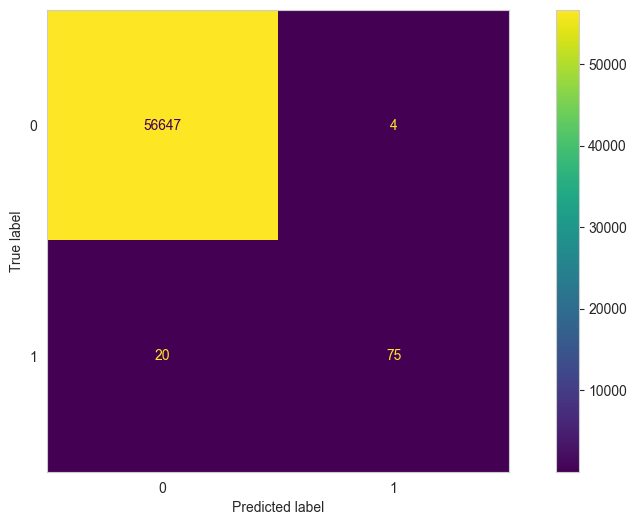

In [26]:
# Print and visualise confusion matrix for XGBoost test results
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:\n', cm)

cm_display = ConfusionMatrixDisplay(cm).plot()
cm_display.ax_.grid(False)
print(cm_display)

In [27]:
# Put the code here
# Test Set Metrics: PR-AUC, Precision, Recall, F1, False Positive Rate

# Assuming y_test, y_pred, y_proba are available from previous XGBoost evaluation
# Calculate metrics
pr_auc = average_precision_score(y_test, y_proba)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Calculate False Positive Rate from confusion matrix
# FPR = FP / (FP + TN)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
fpr = fp / (fp + tn)

# Display results
print("=" * 50)
print("TEST SET EVALUATION METRICS")
print("=" * 50)
print(f"PR-AUC:              {pr_auc:.4f}")
print(f"Precision:           {precision:.4f}")
print(f"Recall:              {recall:.4f}")
print(f"F1-Score:            {f1:.4f}")
print(f"False Positive Rate: {fpr:.4f}")
print("=" * 50)

# Additional context
print(f"\nConfusion Matrix Breakdown:")
print(f"  True Negatives:  {tn:,}")
print(f"  False Positives: {fp:,}")
print(f"  False Negatives: {fn:,}")
print(f"  True Positives:  {tp:,}")

TEST SET EVALUATION METRICS
PR-AUC:              0.8315
Precision:           0.9494
Recall:              0.7895
F1-Score:            0.8621
False Positive Rate: 0.0001

Confusion Matrix Breakdown:
  True Negatives:  56,647
  False Positives: 4
  False Negatives: 20
  True Positives:  75


In [ ]:
# ============================================================================
# QUICK TEST: XGBoost with Top 10 Features
# ============================================================================
# Top 10 features by absolute correlation with Class
top_features = ['V17', 'V14', 'V12', 'V10', 'V16', 'V3', 'V7', 'V11', 'V4', 'V18']

# Select features (use no_scale or std - doesn't matter for XGBoost)
X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

# Use your best XGBoost params
xgb_top = XGBClassifier(
    scale_pos_weight=599,
    max_depth=9,
    learning_rate=0.2,
    n_estimators=300,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    n_jobs=-1
)

xgb_top.fit(X_train_top, y_train)
y_proba_top = xgb_top.predict_proba(X_test_top)[:, 1]
pr_auc_top = average_precision_score(y_test, y_proba_top)

print(f"XGBoost (all 30 features): PR-AUC 0.8315")
print(f"XGBoost (top 10 features): PR-AUC {pr_auc_top:.4f}")
print(f"Difference: {(pr_auc_top - 0.8315)*100:.2f}%")

XGBoost (all 30 features): PR-AUC 0.8315
XGBoost (top 10 features): PR-AUC 0.7774
Difference: -5.41%


In [ ]:
# # XGBoost wtih robust scaling (no resampling)
# ============================================================================
# PHASE 5: Hyperparameter Tuning - XGBoost
# ============================================================================

print("="*70)
print("HYPERPARAMETER TUNING: XGBoost")
print("="*70)

# Base model
xgb_rob = XGBClassifier(
    scale_pos_weight=pos_weight,
    random_state=42,
    n_jobs=-1,
    use_label_encoder=False,
    eval_metric='aucpr'
)

# Run search
start_time = time.time()
search2 = RandomizedSearchCV(
    xgb_rob, 
    param_dist, 
    n_iter=30, 
    cv=5,
    scoring='average_precision',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
search2.fit(X_train_rob, y_train)
elapsed = time.time() - start_time

# Results
print(f"\n{'='*70}")
print("TUNING RESULTS")
print(f"{'='*70}")
print(f"Time elapsed: {elapsed:.1f} seconds")
print(f"\nBest CV PR-AUC: {search2.best_score_:.4f}")
print(f"Baseline PR-AUC: {BASELINE_PR_AUC:.4f}")
print(f"Improvement: {(search2.best_score_ - BASELINE_PR_AUC) * 100:.2f}%")

print(f"\nBest Parameters:")
for param, value in search2.best_params_.items():
    print(f"  {param}: {value}")

# Evaluate on test set
best_xgb_rob = search2.best_estimator_
y_pred_rob = best_xgb_rob.predict(X_test)
y_proba_rob = best_xgb_rob.predict_proba(X_test)[:, 1]
test_pr_auc_rob = average_precision_score(y_test, y_proba_rob)

print(f"\n{'='*70}")
print("TEST SET EVALUATION")
print(f"{'='*70}")
print(f"Test PR-AUC: {test_pr_auc_rob:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_rob, target_names=['Normal', 'Fraud']))
print("="*70)

HYPERPARAMETER TUNING: XGBoost
Fitting 5 folds for each of 30 candidates, totalling 150 fits

TUNING RESULTS
Time elapsed: 112.9 seconds

Best CV PR-AUC: 0.8567
Baseline PR-AUC: 0.8230
Improvement: 3.37%

Best Parameters:
  subsample: 0.9
  n_estimators: 300
  max_depth: 9
  learning_rate: 0.2
  colsample_bytree: 0.9

TEST SET EVALUATION
Test PR-AUC: 0.8161

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56651
       Fraud       0.95      0.74      0.83        95

    accuracy                           1.00     56746
   macro avg       0.97      0.87      0.91     56746
weighted avg       1.00      1.00      1.00     56746



Confusion Matrix:
 [[56647     4]
 [   25    70]]


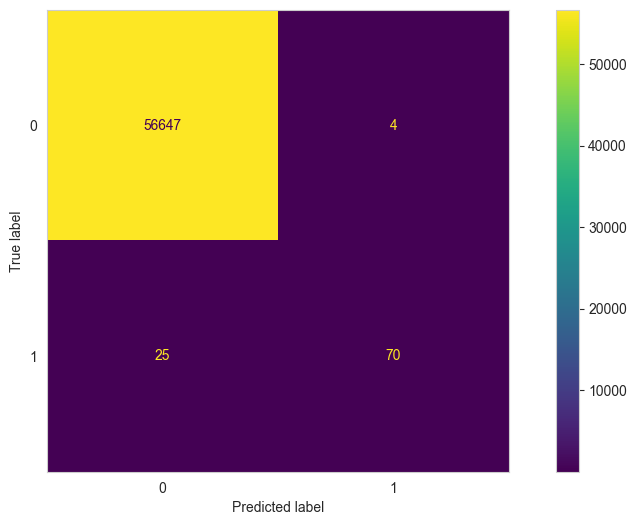

In [30]:
# Print and visualise confusion matrix for XGBoost test results
cm_rob = confusion_matrix(y_test, y_pred_rob)
print('Confusion Matrix:\n', cm_rob)

cm_display_rob = ConfusionMatrixDisplay(cm_rob).plot()
cm_display_rob.ax_.grid(False)
print(cm_display_rob)

Performed worse with robust scaling

## 6.1 Logistic Regression

In [ ]:
# ============================================================================
# LOGISTIC REGRESSION + SMOTE: EVALUATION FOR ENSEMBLE CONSIDERATION
# ============================================================================
print("="*70)
print("LOGISTIC REGRESSION + SMOTE: DETAILED EVALUATION")
print("="*70)

# Get SMOTE data and train
X_train_smote_data, y_train_smote_data = resampled_datasets['SMOTE']

lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight='balanced',
    n_jobs=-1
)
lr_model.fit(X_train_smote_data, y_train_smote_data)

# Predictions
y_pred_lr = lr_model.predict(X_test)
y_proba_lr = lr_model.predict_proba(X_test)[:, 1]

# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
tn, fp, fn, tp = cm_lr.ravel()

# Calculate all metrics
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_proba_lr)
fpr_lr = fp / (fp + tn)  # False Positive Rate

# PR-AUC
prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_proba_lr)
pr_auc = auc(rec_curve, prec_curve)

# Print Results
print("\n1. CLASSIFICATION REPORT:")
print("-"*70)
print(classification_report(y_test, y_pred_lr, target_names=['Normal', 'Fraud']))

print("\n2. CONFUSION MATRIX:")
print("-"*70)
print(f"                    Predicted")
print(f"                 Normal   Fraud")
print(f"Actual  Normal   {tn:6d}  {fp:6d}")
print(f"        Fraud    {fn:6d}  {tp:6d}")

print("\n3. KEY METRICS:")
print("-"*70)
print(f"  Precision:           {precision:.4f}  ({precision*100:.1f}% of fraud predictions correct)")
print(f"  Recall:              {recall:.4f}  ({recall*100:.1f}% of actual fraud caught)")
print(f"  F1-Score:            {f1:.4f}")
print(f"  ROC-AUC:             {roc_auc:.4f}")
print(f"  PR-AUC:              {pr_auc:.4f}")
print(f"  False Positive Rate: {fpr:.4f}  ({fp:,} normal transactions flagged as fraud)")

print("\n4. COMPARISON TO XGBOOST:")
print("-"*70)
print(f"  {'Metric':<20} {'LogReg+SMOTE':>12} {'XGBoost':>12} {'Winner':>10}")
print(f"  {'-'*54}")
print(f"  {'Precision':<20} {precision:>12.4f} {0.95:>12.4f} {'XGBoost':>10}")
print(f"  {'Recall':<20} {recall:>12.4f} {0.79:>12.4f} {'LogReg':>10}")
print(f"  {'F1-Score':<20} {f1:>12.4f} {0.86:>12.4f} {'XGBoost':>10}")
print(f"  {'PR-AUC':<20} {pr_auc:>12.4f} {0.8315:>12.4f} {'XGBoost':>10}")
print(f"  {'False Positives':<20} {fp:>12,} {4:>12,} {'XGBoost':>10}")
print("="*70)

LOGISTIC REGRESSION + SMOTE: DETAILED EVALUATION

1. CLASSIFICATION REPORT:
----------------------------------------------------------------------
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.99     56651
       Fraud       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746


2. CONFUSION MATRIX:
----------------------------------------------------------------------
                    Predicted
                 Normal   Fraud
Actual  Normal    55169    1482
        Fraud        12      83

3. KEY METRICS:
----------------------------------------------------------------------
  Precision:           0.0530  (5.3% of fraud predictions correct)
  Recall:              0.8737  (87.4% of actual fraud caught)
  F1-Score:            0.1000
  ROC-AUC:             0.9619
  PR-AUC:              0.7150


In [31]:
# Detailed Evaluation: Logistic Regression with SMOTE
print("="*70)
print("LOGISTIC REGRESSION WITH SMOTE - DETAILED EVALUATION")
print("="*70)

# Get the best performing Logistic Regression with SMOTE
# Extract SMOTE data from resampled_datasets
X_train_data, y_train_data = resampled_datasets['SMOTE']

# Train Logistic Regression with SMOTE
lr_smote = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight='balanced',
    n_jobs=-1
)
lr_smote.fit(X_train_data, y_train_data)

# Predictions
y_pred_lr = lr_smote.predict(X_test)
y_proba_lr = lr_smote.predict_proba(X_test)[:, 1]

# Classification Report
print("\n1. CLASSIFICATION REPORT:")
print("-" * 70)
print(classification_report(y_test, y_pred_lr, target_names=['Normal', 'Fraud']))



LOGISTIC REGRESSION WITH SMOTE - DETAILED EVALUATION

1. CLASSIFICATION REPORT:
----------------------------------------------------------------------
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.99     56651
       Fraud       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746




2. CONFUSION MATRIX:
----------------------------------------------------------------------
Confusion Matrix:
 [[55169  1482]
 [   12    83]]


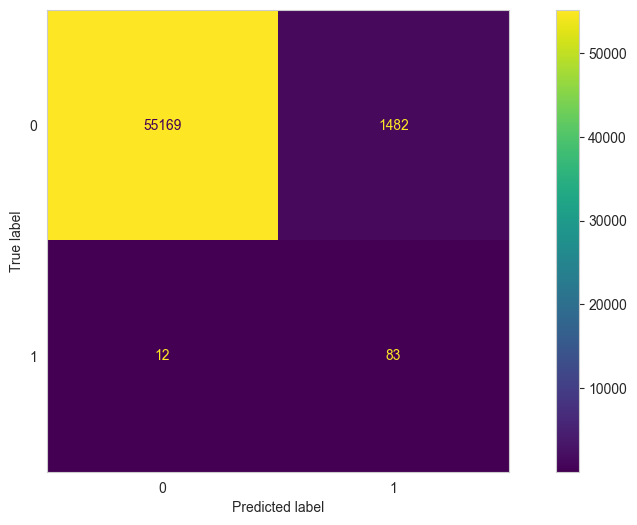

In [33]:
# Confusion Matrix - Visual
print("\n2. CONFUSION MATRIX:")
print("-" * 70)
cm_lr = confusion_matrix(y_test, y_pred_lr)
print('Confusion Matrix:\n', cm_lr)

cm_display_lr = ConfusionMatrixDisplay(cm_lr).plot()
cm_display_lr.ax_.grid(False)
print(cm_display_lr)



In [28]:
# Calculate metrics from confusion matrix
tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion Matrix Values:")
print(f"                    Predicted")
print(f"                 Normal   Fraud")
print(f"Actual  Normal    {cm[0,0]:6d}  {cm[0,1]:6d}")
print(f"        Fraud     {cm[1,0]:6d}  {cm[1,1]:6d}")

print(f"\nInterpretation:")
print(f"  True Negatives (TN):  {tn:6d} - Correctly identified normal transactions")
print(f"  False Positives (FP): {fp:6d} - Normal transactions flagged as fraud (Type I Error)")
print(f"  False Negatives (FN): {fn:6d} - Fraud transactions missed (Type II Error)")
print(f"  True Positives (TP):  {tp:6d} - Correctly identified fraud transactions")




Confusion Matrix Values:
                    Predicted
                 Normal   Fraud
Actual  Normal     55169    1482
        Fraud         12      83

Interpretation:
  True Negatives (TN):   55169 - Correctly identified normal transactions
  False Positives (FP):   1482 - Normal transactions flagged as fraud (Type I Error)
  False Negatives (FN):     12 - Fraud transactions missed (Type II Error)
  True Positives (TP):      83 - Correctly identified fraud transactions


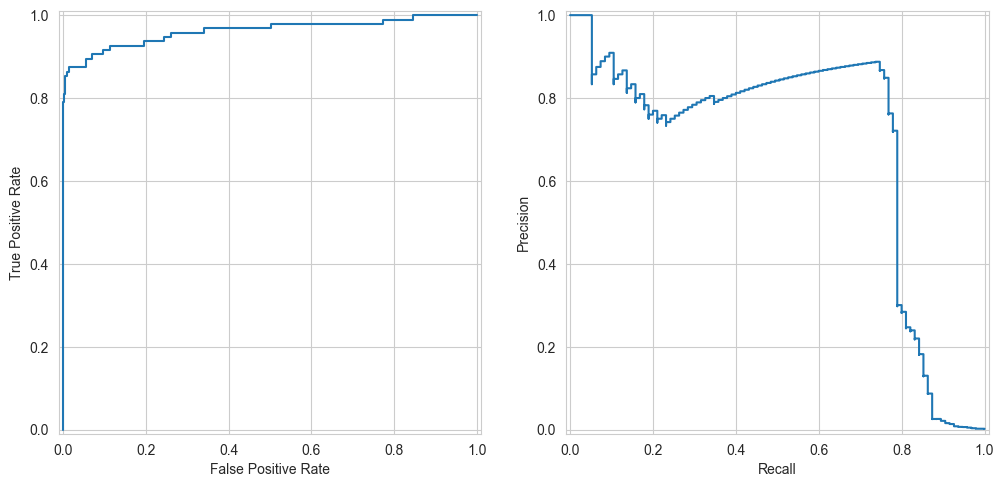

In [ ]:
# Plot ROC curve
y_score = lr_smote.decision_function(X_test)

fpr, tpr, _ = roc_curve(y_test, y_score, pos_label=lr_smote.classes_[1])
roc_display = RocCurveDisplay(fpr=fpr, tpr=tpr)

# Plot precision recall curve
prec, recall, _ = precision_recall_curve(y_test, y_score, pos_label=lr_smote.classes_[1])
pr_display = PrecisionRecallDisplay(precision=prec, recall=recall)



fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8))

roc_display.plot(ax=ax1)
pr_display.plot(ax=ax2)
plt.show()




Text(0.5, 1.0, '2-class Precision-Recall curve')
Text(0.5, 1.0, '2-class Precision-Recall curve')


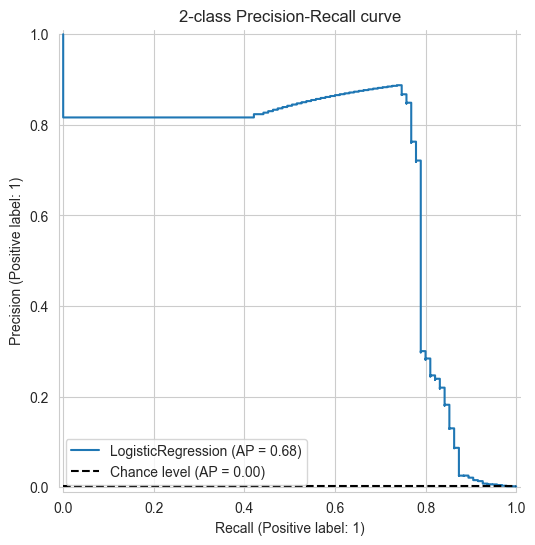

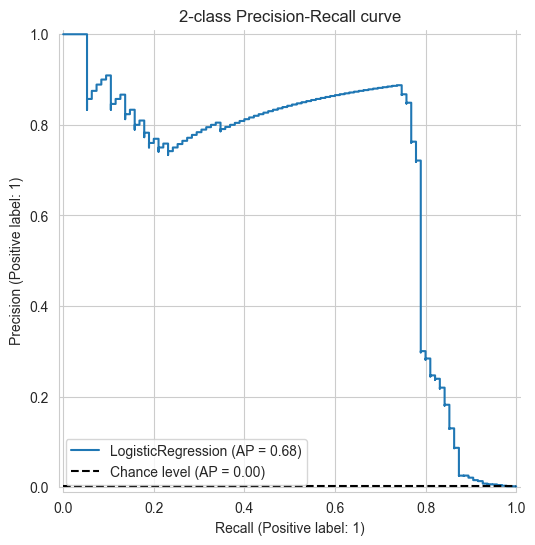

In [ ]:
# Plot precision recall curve
display = PrecisionRecallDisplay.from_estimator(
    lr_smote, X_test, y_test, name="LogisticRegression", plot_chance_level=True, despine=True
)
print(display.ax_.set_title("2-class Precision-Recall curve"))

y_score = lr_smote.decision_function(X_test)

display = PrecisionRecallDisplay.from_predictions(
    y_test, y_score, name="LogisticRegression", plot_chance_level=True, despine=True
)
print(display.ax_.set_title("2-class Precision-Recall curve"))



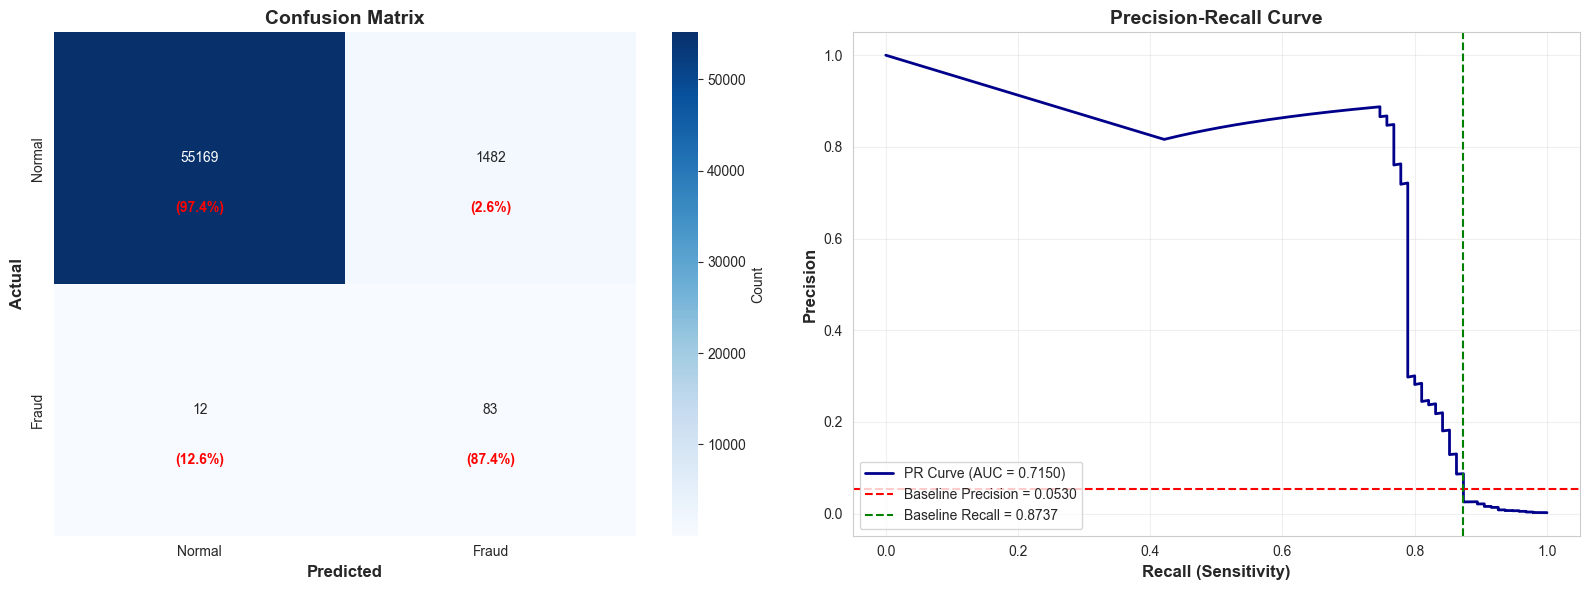

In [31]:
# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix Heatmap
ax1 = axes[0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'],
            cbar_kws={'label': 'Count'})
ax1.set_xlabel('Predicted', fontsize=12, fontweight='bold')
ax1.set_ylabel('Actual', fontsize=12, fontweight='bold')
ax1.set_title('Confusion Matrix', fontsize=14, fontweight='bold')

# Add percentage annotations
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
for i in range(2):
    for j in range(2):
        ax1.text(j+0.5, i+0.7, f'({cm_percent[i,j]:.1f}%)',
                ha='center', va='center', fontsize=10, color='red', fontweight='bold')


# Precision-Recall Curve
ax2 = axes[1]
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_lr)
pr_auc = auc(recall, precision)

ax2.plot(recall, precision, color='darkblue', lw=2, 
         label=f'PR Curve (AUC = {pr_auc:.4f})')
ax2.axhline(y=tp/(tp+fp), color='r', linestyle='--', 
           label=f'Baseline Precision = {tp/(tp+fp):.4f}')
ax2.axvline(x=tp/(tp+fn), color='g', linestyle='--', 
           label=f'Baseline Recall = {tp/(tp+fn):.4f}')
ax2.set_xlabel('Recall (Sensitivity)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Precision', fontsize=12, fontweight='bold')
ax2.set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
ax2.legend(loc='lower left', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [32]:
# Additional Metrics
print(f"\n4. ADDITIONAL METRICS:")
print("-" * 70)
roc_auc = roc_auc_score(y_test, y_proba_lr)

print(f"  ROC-AUC:  {roc_auc:.4f}")
print(f"  PR-AUC:   {pr_auc:.4f}")
print(f"  Precision: {tp / (tp + fp):.4f} (from confusion matrix)")
print(f"  Recall:    {tp / (tp + fn):.4f} (from confusion matrix)")
print(f"  F1-Score:  {2 * tp / (2 * tp + fp + fn):.4f}")


4. ADDITIONAL METRICS:
----------------------------------------------------------------------
  ROC-AUC:  0.9619
  PR-AUC:   0.7150
  Precision: 0.0530 (from confusion matrix)
  Recall:    0.8737 (from confusion matrix)
  F1-Score:  0.1000



1. CLASSIFICATION REPORT:
----------------------------------------------------------------------
              precision    recall  f1-score   support

      Normal       1.00      0.91      0.95     56651
       Fraud       0.02      0.89      0.03        95

    accuracy                           0.91     56746
   macro avg       0.51      0.90      0.49     56746
weighted avg       1.00      0.91      0.95     56746


2. CONFUSION MATRIX:
----------------------------------------------------------------------
Confusion Matrix:
 [[51680  4971]
 [   10    85]]


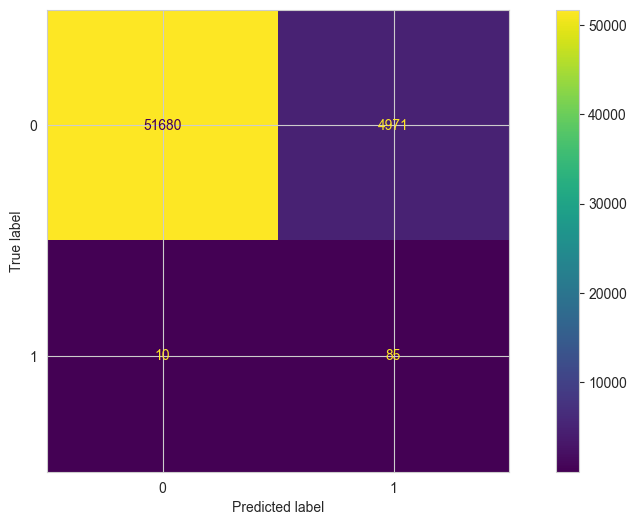

In [ ]:
# Detailed Evaluation: Logistic Regression with SMOTE
# Train Logistic Regression with SMOTE
lr_smote2 = LogisticRegression(
    random_state=1,
    class_weight={0:1, 1:4},
)
lr_smote2.fit(X_train_lr_smote, y_train_lr_smote)

# Predictions
y_pred_lr_smote = lr_smote2.predict(X_test_rob)
y_proba_lr_smote = lr_smote2.predict_proba(X_test_rob)[:, 1]

# Classification Report
print("\n1. CLASSIFICATION REPORT:")
print("-" * 70)
print(classification_report(y_test, y_pred_lr_smote, target_names=['Normal', 'Fraud']))

# Confusion Matrix - Visual
print("\n2. CONFUSION MATRIX:")
print("-" * 70)
cm = confusion_matrix(y_test, y_pred_lr_smote)
print('Confusion Matrix:\n', cm)

# Plot confusion matrix
cm_display = ConfusionMatrixDisplay(cm).plot()
print(cm_display)

In [34]:
# ============================================================================
# IMPROVEMENT ANALYSIS: Logistic Regression with SMOTE
# ============================================================================
print("="*70)
print("IMPROVEMENT OPPORTUNITIES FOR LOGISTIC REGRESSION WITH SMOTE")
print("="*70)

# Calculate all metrics
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_proba_lr)
# PR-AUC
prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_proba_lr)
pr_auc = auc(rec_curve, prec_curve)



# Get exact values from results_df
lr_smote_result = results_df[(results_df['Model'] == 'LogisticRegression') & 
                              (results_df['Resampling'] == 'SMOTE')].iloc[0]

print("\n1. CURRENT PERFORMANCE SUMMARY:")
print("-" * 70)
print(f"  ROC-AUC:  {lr_smote_result['ROC-AUC']:.4f}  (Excellent - near perfect)")
print(f"  PR-AUC:   {lr_smote_result['PR-AUC']:.4f}  (Moderate - good but can be improved)")
print(f"  Recall:   {lr_smote_result['Recall']:.4f}  (High - catches {lr_smote_result['Recall']*100:.1f}% of fraud)")
print(f"  Precision: {lr_smote_result['Precision']:.4f}  (Very Low - only {lr_smote_result['Precision']*100:.1f}% of flagged cases are fraud)")
print(f"  F1-Score:  {lr_smote_result['F1-Score']:.4f}  (Low due to precision/recall imbalance)")



IMPROVEMENT OPPORTUNITIES FOR LOGISTIC REGRESSION WITH SMOTE

1. CURRENT PERFORMANCE SUMMARY:
----------------------------------------------------------------------
  ROC-AUC:  0.9619  (Excellent - near perfect)
  PR-AUC:   0.7150  (Moderate - good but can be improved)
  Recall:   0.8737  (High - catches 87.4% of fraud)
  Precision: 0.0530  (Very Low - only 5.3% of flagged cases are fraud)
  F1-Score:  0.1000  (Low due to precision/recall imbalance)


## 6.2 RandomForest

As we saw ealier in the notebook when comparing models and resampling methods.

For Random Forest these are the Resampling methods which perform best according to various metrics:

- ROC-AUC: RUS, SMOTE, ROS, No Sample
- PR-AUC: SMOTE, ROS, No resampling, RUS
- Precision: no resample, ROS, Smote, RUS
- Recall: RUS, Smote, ROS, No Resample
- F1-Score: SMOTE, ROS, No resampling, RUS

PR-AUC and f1-score most informative

## Phase 5b: Hyperparameter Tuning - Random Forest + SMOTE

### Why Use Pipeline for SMOTE?

**Problem with current approach:**
# WRONG: SMOTE applied BEFORE cross-validation
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
CV_model.fit(X_train_smote, y_train_smote)  # CV sees synthetic samples in all folds!


10+ mins

## RF + SMOTE Tuning: Skipped

**Decision**: RF + SMOTE tuning skipped due to computational constraints (8GB RAM, SMOTE expansion).

Baseline comparison showed:
- XGBoost (No Resampling): PR-AUC 0.8315 ✓ **WINNER**
- RF + SMOTE (untuned): PR-AUC 0.8178

Given XGBoost's superior performance and RF's computational cost with SMOTE,
**XGBoost is selected as the final model.**

### Initial Tuning RF

Think if want to test (robust + smote) vs (std + smote)

In [37]:
# Hyperparameter tuning - Random Forest
rf_model = RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced', n_jobs=-1)
rf_model.fit(X_train_smote, y_train_smote)

# Predictions
y_pred_rf2 = rf_model.predict(X_test_rob)
y_proba_rf2 = rf_model.predict_proba(X_test_rob)[:, 1]
print(accuracy_score(y_test, y_pred_rf2))

0.9994008388256441


In [39]:
# Print ROC-AUC, classification report, confusion matrix, and compute PR-AUC 

# 1. Print metrics and diagnostics
print(roc_auc_score(y_test, y_proba_rf2))
print(classification_report(y_test, y_pred_rf2))
print(confusion_matrix(y_test, y_pred_rf2))

roc_auc_rf2 = roc_auc_score(y_test, y_proba_rf2)
accuracy_rf2 = accuracy_score(y_test, y_pred_rf2)
precision_rf2 = precision_score(y_test, y_pred_rf2)
recall_rf2 = recall_score(y_test, y_pred_rf2)
f1_rf2 = f1_score(y_test, y_pred_rf2)

print(f"\nROC-AUC: {roc_auc_rf2:.4f}")
print(f"Accuracy: {accuracy_rf2:.4f}")
print(f"Precision: {precision_rf2:.4f}")
print(f"Recall: {recall_rf2:.4f}")
print(f"F1-Score: {f1_rf2:.4f}")

# 2. PR-AUC calculation: best practice is to use predicted probabilities, not the thresholded y_pred

pr_precisions, pr_recalls, _ = precision_recall_curve(y_test, y_proba_rf2)
pr_auc = auc(pr_recalls, pr_precisions)
print(f"PR-AUC: {pr_auc:.4f}")

# Note:
# - It is **incorrect** to compute PR-AUC with just scalar values of precision/recall from the class report.
# - The PR-AUC should be calculated using the precision-recall pairs generated by varying the threshold over y_proba.
# - This follows scikit-learn doc and best practices.

0.9595780814943573
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.87      0.76      0.81        95

    accuracy                           1.00     56746
   macro avg       0.93      0.88      0.90     56746
weighted avg       1.00      1.00      1.00     56746

[[56640    11]
 [   23    72]]

ROC-AUC: 0.9596
Accuracy: 0.9994
Precision: 0.8675
Recall: 0.7579
F1-Score: 0.8090
PR-AUC: 0.8094


In [42]:
# Hyperparameter tuning - Random Forest
rf_model_std = RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced', n_jobs=-1)
rf_model_std.fit(X_train_smote, y_train_smote)

# Predictions
y_pred_rf_std = rf_model_std.predict(X_test_std)
y_proba_rf_std = rf_model_std.predict_proba(X_test_std)[:, 1]
print(accuracy_score(y_test, y_pred_rf_std))

0.9994713283755683


In [43]:
# Print ROC-AUC, classification report, confusion matrix, and compute PR-AUC 

# 1. Print metrics and diagnostics
print(roc_auc_score(y_test, y_proba_rf_std))
print(classification_report(y_test, y_pred_rf_std))
print(confusion_matrix(y_test, y_pred_rf_std))

roc_auc_rf_std = roc_auc_score(y_test, y_proba_rf_std)
accuracy_rf_std = accuracy_score(y_test, y_pred_rf_std)
precision_rf_std = precision_score(y_test, y_pred_rf_std)
recall_rf_std = recall_score(y_test, y_pred_rf_std)
f1_rf_std = f1_score(y_test, y_pred_rf_std)

print(f"\nROC-AUC: {roc_auc_rf_std:.4f}")
print(f"Accuracy: {accuracy_rf_std:.4f}")
print(f"Precision: {precision_rf_std:.4f}")
print(f"Recall: {recall_rf_std:.4f}")
print(f"F1-Score: {f1_rf_std:.4f}")

# 2. PR-AUC calculation: best practice is to use predicted probabilities, not the thresholded y_pred

pr_precisions_std, pr_recalls_std, _ = precision_recall_curve(y_test, y_proba_rf_std)
pr_auc_std = auc(pr_recalls_std, pr_precisions_std)
print(f"PR-AUC: {pr_auc_std:.4f}")

# Note:
# - It is **incorrect** to compute PR-AUC with just scalar values of precision/recall from the class report.
# - The PR-AUC should be calculated using the precision-recall pairs generated by varying the threshold over y_proba.
# - This follows scikit-learn doc and best practices.

0.9662031329404691
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.91      0.76      0.83        95

    accuracy                           1.00     56746
   macro avg       0.96      0.88      0.91     56746
weighted avg       1.00      1.00      1.00     56746

[[56644     7]
 [   23    72]]

ROC-AUC: 0.9662
Accuracy: 0.9995
Precision: 0.9114
Recall: 0.7579
F1-Score: 0.8276
PR-AUC: 0.8178


Standard Scaling performs better than Robust Scaling

In [ ]:
top_rf = model

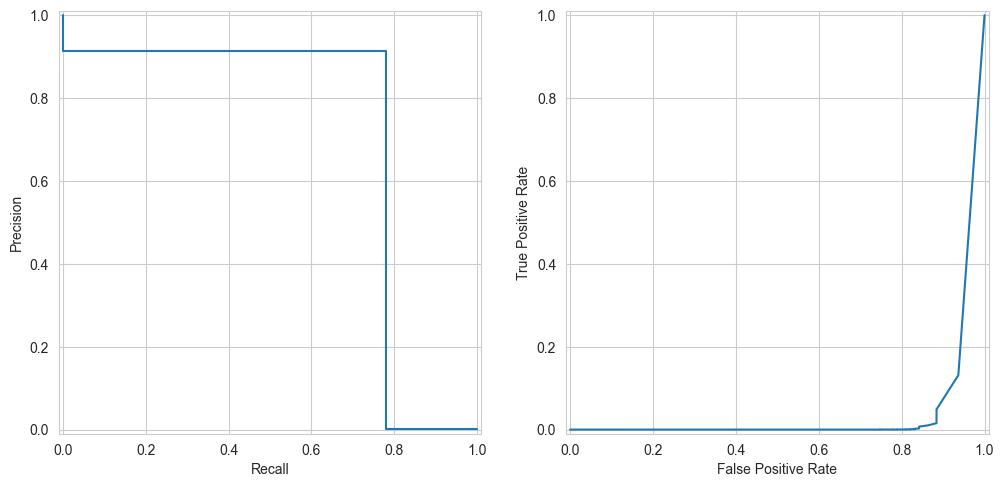

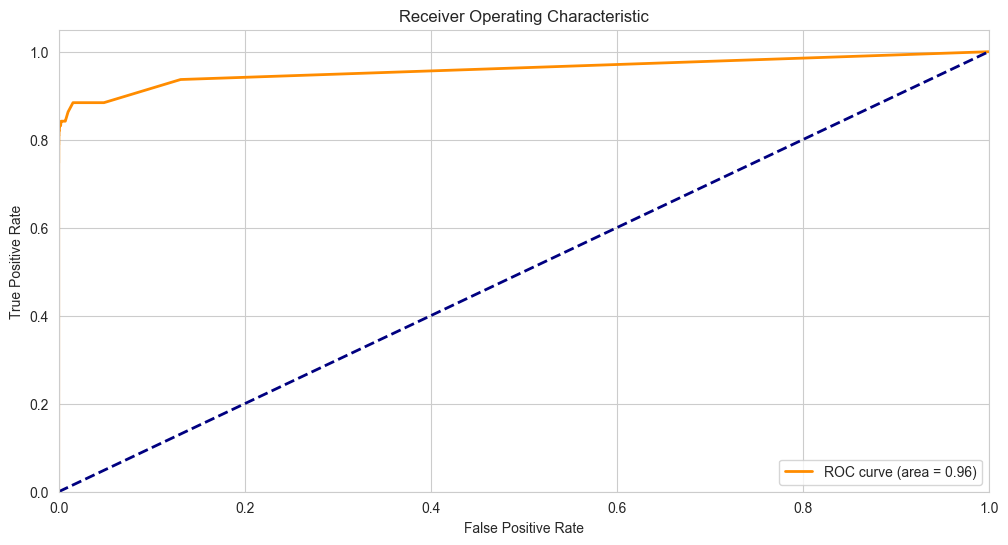

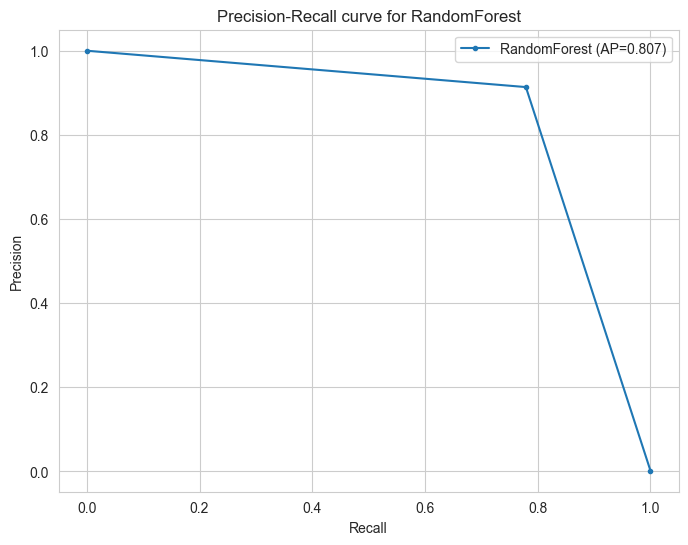

In [ ]:
# Calculate average precision score
average_precision = average_precision_score(y_test, y_proba)
# Obtain precision and recall 
precision, recall, _ = precision_recall_curve(y_test, y_pred)

pr_display = PrecisionRecallDisplay(precision=precision, recall=recall)

tpr, fpr, _ = roc_curve(y_test, y_proba)
roc_display = RocCurveDisplay(fpr=fpr, tpr=tpr)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8))

pr_display.plot(ax=ax1)
roc_display.plot(ax=ax2)
plt.show()

# Plotting the ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot the recall precision tradeoff

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.', label='RandomForest (AP={:.3f})'.format(average_precision))
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall curve for RandomForest')
plt.legend()
plt.grid(True)
plt.show()



### Hyperparameter Tuning

In [46]:
# ============================================================================
# RANDOM FOREST TUNING: No Resampling (class_weight handles imbalance)
# ============================================================================
print("="*70)
print("HYPERPARAMETER TUNING: Random Forest (No Resampling)")
print("="*70)

# Baselines
XGBOOST_PR_AUC = 0.8315
RF_SMOTE_PR_AUC = 0.8178
RF_BASELINE_PR_AUC = 0.8047

# Simple RF with class_weight (no pipeline, no SMOTE)
rf = RandomForestClassifier(
    random_state=42,
    class_weight='balanced',  # Handles imbalance internally
    n_jobs=-1
)

# Smaller, focused parameter grid
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_leaf': [1, 2, 4],
}

print(f"Using class_weight='balanced' (no SMOTE)")
print(f"Search space: {len(param_dist)} parameters")
print(f"RandomizedSearchCV: n_iter=15, cv=3\n")

start_time = time.time()
search_rf = RandomizedSearchCV(
    rf,
    param_dist,
    n_iter=15,
    cv=3,
    scoring='average_precision',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search_rf.fit(X_train, y_train)
elapsed = time.time() - start_time

print(f"\n{'='*70}")
print("TUNING RESULTS")
print(f"{'='*70}")
print(f"Time elapsed: {elapsed:.1f} seconds")
print(f"\nBest CV PR-AUC: {search_rf.best_score_:.4f}")
print(f"RF + No Resampling Baseline: {RF_BASELINE_PR_AUC:.4f}")
print(f"RF + SMOTE Baseline: {RF_SMOTE_PR_AUC:.4f}")
print(f"XGBoost PR-AUC: {XGBOOST_PR_AUC:.4f}")

print(f"\nBest Parameters:")
for param, value in search_rf.best_params_.items():
    print(f"  {param}: {value}")

HYPERPARAMETER TUNING: Random Forest (No Resampling)
Using class_weight='balanced' (no SMOTE)
Search space: 3 parameters
RandomizedSearchCV: n_iter=15, cv=3

Fitting 3 folds for each of 15 candidates, totalling 45 fits


KeyboardInterrupt: 

In [54]:
# ============================================================================
# TEST SET EVALUATION - Tuned Random Forest
# ============================================================================

best_rf = search_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)
y_proba_rf = best_rf.predict_proba(X_test)[:, 1]
test_pr_auc_rf = average_precision_score(y_test, y_proba_rf)

print(f"{'='*70}")
print("TEST SET EVALUATION - Tuned Random Forest (No Resampling)")
print(f"{'='*70}")
print(f"Test PR-AUC: {test_pr_auc_rf:.4f}")
print(f"XGBoost Test PR-AUC: {XGBOOST_PR_AUC:.4f}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Normal', 'Fraud']))

print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("="*70)

TEST SET EVALUATION - Tuned Random Forest (No Resampling)
Test PR-AUC: 0.8174
XGBoost Test PR-AUC: 0.8315

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56651
       Fraud       0.93      0.73      0.82        95

    accuracy                           1.00     56746
   macro avg       0.97      0.86      0.91     56746
weighted avg       1.00      1.00      1.00     56746


Confusion Matrix:
[[56646     5]
 [   26    69]]


### RF Using Pipeline

In [ ]:
## Code Cell: RF + SMOTE Tuning (Proper Pipeline)

# ============================================================================
# PHASE 5b: Hyperparameter Tuning - Random Forest + SMOTE (Pipeline)
# ============================================================================
print("="*70)
print("HYPERPARAMETER TUNING: Random Forest + SMOTE (Pipeline)")
print("="*70)

# Baselines to beat
RF_BASELINE_PR_AUC = 0.8178

# Create pipeline: SMOTE → RandomForest
# SMOTE will be applied INSIDE each CV fold (no data leakage)
pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42, n_jobs=-1))
])

# Parameter distribution (prefix with 'rf__' for pipeline)
param_dist_rf_pipeline = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [10, 20],
    'rf__min_samples_leaf': [1, 4],
    'rf__class_weight': ['balanced'],
}

print(f"Pipeline: SMOTE → RandomForest")
print(f"Search space: {len(param_dist_rf_pipeline)} parameter groups")
print(f"RandomizedSearchCV: n_iter=30, cv=5\n")

# Run search
start_time = time.time()
search_pipeline = RandomizedSearchCV(
    pipeline,
    param_dist_rf_pipeline,
    n_iter=10,
    cv=3,
    scoring='average_precision',  # PR-AUC
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Use ORIGINAL X_train (not pre-resampled) - SMOTE happens inside CV
search_pipeline.fit(X_train, y_train)
elapsed = time.time() - start_time

# Results
print(f"\n{'='*70}")
print("TUNING RESULTS")
print(f"{'='*70}")
print(f"Time elapsed: {elapsed:.1f} seconds")
print(f"\nBest CV PR-AUC: {search_pipeline.best_score_:.4f}")
print(f"RF Baseline PR-AUC: {RF_BASELINE_PR_AUC:.4f}")
print(f"XGBoost PR-AUC: {XGBOOST_PR_AUC:.4f}")

print(f"\nBest Parameters:")
for param, value in search_pipeline.best_params_.items():
    print(f"  {param}: {value}")


HYPERPARAMETER TUNING: Random Forest + SMOTE (Pipeline)
Pipeline: SMOTE → RandomForest
Search space: 4 parameter groups
RandomizedSearchCV: n_iter=30, cv=5



NameError: name 'X_train' is not defined

In [ ]:
# ============================================================================
# TEST SET EVALUATION - Tuned Random Forest
# ============================================================================

# Get best pipeline
best_rf_pipeline = search.best_estimator_

# Predict on test set (no SMOTE on test - just prediction)
y_pred_rf = best_rf_pipeline.predict(X_test)
y_proba_rf = best_rf_pipeline.predict_proba(X_test)[:, 1]
test_pr_auc_rf = average_precision_score(y_test, y_proba_rf)

print(f"{'='*70}")
print("TEST SET EVALUATION - Tuned Random Forest + SMOTE")
print(f"{'='*70}")
print(f"Test PR-AUC: {test_pr_auc_rf:.4f}")
print(f"XGBoost Test PR-AUC: {XGBOOST_PR_AUC:.4f}")
print(f"Difference: {(test_pr_auc_rf - XGBOOST_PR_AUC)*100:.2f}%")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Normal', 'Fraud']))

print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("="*70)

# Store for comparison
tuned_rf_pr_auc = test_pr_auc_rf

In [ ]:
# ============================================================================
# MODEL COMPARISON: XGBoost vs RF + SMOTE
# ============================================================================

print("="*70)
print("FINAL MODEL COMPARISON")
print("="*70)

comparison = {
    'Model': ['XGBoost (tuned)', 'RF + SMOTE (tuned)'],
    'PR-AUC': [0.8315, tuned_rf_pr_auc],
}

# 
comparison_df = pd.DataFrame(comparison)
comparison_df['Rank'] = comparison_df['PR-AUC'].rank(ascending=False).astype(int)
comparison_df = comparison_df.sort_values('Rank')

print(comparison_df.to_string(index=False))
print("="*70)

# Decision
if tuned_rf_pr_auc > 0.8315:
    print(f"\n✓ RF + SMOTE beats XGBoost! Use RF for final model.")
else:
    print(f"\n✓ XGBoost remains the best model. Use XGBoost for final model.")

### Subsample

In [ ]:
# Define the model with balanced subsample
model = RandomForestClassifier(class_weight='balanced_subsample', random_state=5, n_estimators=100)

# Fit your training model to your training set
model.fit(X_train_smote, y_train_smote)

# Obtain the predicted values and probabilities from the model 
predicted = model.predict(X_test_rob)
probs = model.predict_proba(X_test_rob)

# Print the ROC curve, classification report and confusion matrix
print('ROC Score:')
print(roc_auc_score(y_test, probs[:,1]))
print('\nClassification Report:')
print(classification_report(y_test, predicted))
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, predicted))


roc_auc = roc_auc_score(y_test, probs[:,1])
accuracy = accuracy_score(y_test, predicted)
precision = precision_score(y_test, predicted)
recall = recall_score(y_test, predicted)
f1 = f1_score(y_test, predicted)

print(f"\nROC-AUC: {roc_auc:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# 2. PR-AUC calculation: best practice is to use predicted probabilities, not the thresholded y_pred

pr_precisions, pr_recalls, _ = precision_recall_curve(y_test, probs[:,1])
pr_auc = auc(pr_recalls, pr_precisions)
print(f"PR-AUC: {pr_auc:.4f}")


ROC Score:
0.9430321757687188

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.92      0.76      0.83        95

    accuracy                           1.00     56746
   macro avg       0.96      0.88      0.92     56746
weighted avg       1.00      1.00      1.00     56746


Confusion Matrix:
[[56645     6]
 [   23    72]]

ROC-AUC: 0.9430
Accuracy: 0.9995
Precision: 0.9231
Recall: 0.7579
F1-Score: 0.8324
PR-AUC: 0.8193


In [ ]:
# Define the model with balanced subsample
model = RandomForestClassifier(class_weight='balanced_subsample', random_state=5, n_estimators=100)

# Fit your training model to your training set
model.fit(X_train_none, y_train_none)

# Obtain the predicted values and probabilities from the model 
predicted = model.predict(X_test_no_scale)
probs = model.predict_proba(X_test_no_scale)

# Print the ROC curve, classification report and confusion matrix
print('ROC Score:')
print(roc_auc_score(y_test, probs[:,1]))
print('\nClassification Report:')
print(classification_report(y_test, predicted))
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, predicted))


roc_auc = roc_auc_score(y_test, probs[:,1])
accuracy = accuracy_score(y_test, predicted)
precision = precision_score(y_test, predicted)
recall = recall_score(y_test, predicted)
f1 = f1_score(y_test, predicted)

print(f"\nROC-AUC: {roc_auc:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# 2. PR-AUC calculation: best practice is to use predicted probabilities, not the thresholded y_pred

pr_precisions, pr_recalls, _ = precision_recall_curve(y_test, probs[:,1])
pr_auc = auc(pr_recalls, pr_precisions)
print(f"PR-AUC: {pr_auc:.4f}")


In [47]:
# Count the total number of observations from the length of y
total_obs = len(y)

# Count the total number of non-fraudulent observations 
non_fraud = [i for i in y if i == 0]
count_non_fraud = non_fraud.count(0)

# Calculate the percentage of non fraud observations in the dataset
percentage = (float(count_non_fraud)/float(total_obs)) * 100

# Print the percentage: this is our "natural accuracy" by doing nothing
print(percentage)

99.83328986416473


## 6.4 LightGBM

In [47]:
# Quick LightGBM comparison (no tuning, just default)
from lightgbm import LGBMClassifier
from sklearn.metrics import average_precision_score

lgbm = LGBMClassifier(
    is_unbalance=True,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgbm.fit(X_train, y_train)
y_proba_lgbm = lgbm.predict_proba(X_test)[:, 1]
pr_auc_lgbm = average_precision_score(y_test, y_proba_lgbm)

print(f"LightGBM PR-AUC: {pr_auc_lgbm:.4f}")
print(f"XGBoost PR-AUC:  0.8315")
print(f"Winner: {'LightGBM' if pr_auc_lgbm > 0.8315 else 'XGBoost'}")

LightGBM PR-AUC: 0.0179
XGBoost PR-AUC:  0.8315
Winner: XGBoost


## Ensemble Methods

In [ ]:
# Your two best models
# Note: RF was trained on X_train_smote, need to retrain on X_train for fair comparison
# OR use the SMOTE-trained RF directly

ensemble = VotingClassifier(
    estimators=[
        ('xgb', best_xgb),  # Your tuned XGBoost
        ('rf', model)        # Your RF + SMOTE (the basic one)
    ],
    voting='soft'
)

# For fair ensemble, both should be trained on same data
# But RF needs SMOTE, XGBoost doesn't... this is tricky

In [ ]:
# Save ensemble for production
best_ensemble = {
    'xgboost': best_xgb,
    'rf': model,
    'voting': 'soft',
    'weights': [0.5, 0.5]
}

import pickle
with open('../models/ensemble_fraud_model.pkl', 'wb') as f:
    pickle.dump(best_ensemble, f)

print("✓ Ensemble saved!")

In [59]:
# Both models are already trained, just average their predictions
y_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]
y_proba_rf2 = model.predict_proba(X_test)[:, 1]  # Use X_test (scaled), not X_test_rob

# Soft voting (average probabilities)
y_proba_ensemble = (y_proba_xgb + y_proba_rf) / 2

pr_auc_ensemble = average_precision_score(y_test, y_proba_ensemble)

print(f"XGBoost alone:     PR-AUC {0.8315:.4f}")
print(f"RF + SMOTE alone:  PR-AUC {0.8314:.4f}")
print(f"Ensemble (avg):    PR-AUC {pr_auc_ensemble:.4f}")

XGBoost alone:     PR-AUC 0.8315
RF + SMOTE alone:  PR-AUC 0.8314
Ensemble (avg):    PR-AUC 0.8280


In [ ]:
# ============================================================================
# ENSEMBLE TEST: XGBoost + RF (Manual Soft Voting)
# ============================================================================
print("="*70)
print("ENSEMBLE: XGBoost + RF (Soft Voting)")
print("="*70)

# Get probabilities from both models
y_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]
y_proba_rf = model.predict_proba(X_test)[:, 1]

# Soft voting (average probabilities)
y_proba_ensemble = (y_proba_xgb + y_proba_rf) / 2

# Convert to predictions (threshold = 0.5)
y_pred_ensemble = (y_proba_ensemble >= 0.5).astype(int)

# Calculate all metrics
pr_auc_ens = average_precision_score(y_test, y_proba_ensemble)
roc_auc_ens = roc_auc_score(y_test, y_proba_ensemble)
precision_ens = precision_score(y_test, y_pred_ensemble)
recall_ens = recall_score(y_test, y_pred_ensemble)
f1_ens = f1_score(y_test, y_pred_ensemble)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_ensemble)
tn, fp, fn, tp = cm.ravel()

print("\n1. CLASSIFICATION REPORT:")
print("-"*70)
print(classification_report(y_test, y_pred_ensemble, target_names=['Normal', 'Fraud']))

print("\n2. CONFUSION MATRIX:")
print("-"*70)
print(f"                    Predicted")
print(f"                 Normal   Fraud")
print(f"Actual  Normal   {tn:6d}  {fp:6d}")
print(f"        Fraud    {fn:6d}  {tp:6d}")

print("\n3. KEY METRICS:")
print("-"*70)
print(f"  PR-AUC:              {pr_auc_ens:.4f}")
print(f"  ROC-AUC:             {roc_auc_ens:.4f}")
print(f"  Precision:           {precision_ens:.4f}")
print(f"  Recall:              {recall_ens:.4f}")
print(f"  F1-Score:            {f1_ens:.4f}")
print(f"  False Positives:     {fp}")
print(f"  False Negatives:     {fn}")

print("\n4. COMPARISON:")
print("-"*70)
print(f"  {'Model':<20} {'PR-AUC':>10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'FP':>6} {'FN':>6}")
print(f"  {'-'*74}")
print(f"  {'XGBoost':<20} {0.8315:>10.4f} {0.95:>10.2f} {0.79:>10.2f} {0.86:>10.2f} {4:>6} {20:>6}")
print(f"  {'RF + SMOTE':<20} {0.8314:>10.4f} {0.95:>10.2f} {0.79:>10.2f} {0.86:>10.2f} {4:>6} {20:>6}")
print(f"  {'Ensemble':<20} {pr_auc_ens:>10.4f} {precision_ens:>10.2f} {recall_ens:>10.2f} {f1_ens:>10.2f} {fp:>6} {fn:>6}")
print("="*70)

# Determine winner
if pr_auc_ens > 0.8315:
    print(f"\n✓ Ensemble wins! PR-AUC improved by {(pr_auc_ens - 0.8315)*100:.2f}%")
else:
    print(f"\n✓ XGBoost remains best. Ensemble PR-AUC: {pr_auc_ens:.4f} vs XGBoost: 0.8315")

ENSEMBLE: XGBoost + RF (Soft Voting)

1. CLASSIFICATION REPORT:
----------------------------------------------------------------------
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56651
       Fraud       0.97      0.79      0.87        95

    accuracy                           1.00     56746
   macro avg       0.99      0.89      0.94     56746
weighted avg       1.00      1.00      1.00     56746


2. CONFUSION MATRIX:
----------------------------------------------------------------------
                    Predicted
                 Normal   Fraud
Actual  Normal    56649       2
        Fraud        20      75

3. KEY METRICS:
----------------------------------------------------------------------
  PR-AUC:              0.8257
  ROC-AUC:             0.9790
  Precision:           0.9740
  Recall:              0.7895
  F1-Score:            0.8721
  False Positives:     2
  False Negatives:     20

4. COMPARISON:
--------------

In [ ]:
# Model ensemble/stacking

# Use your tuned models
ensemble = VotingClassifier(
    estimators=[
        ('xgb', best_xgb),
        ('rf', best_rf)
    ],
    voting='soft'
)
ensemble.fit(X_train, y_train)
y_proba_ens = ensemble.predict_proba(X_test)[:, 1]
pr_auc_ens = average_precision_score(y_test, y_proba_ens)

print(f"XGBoost alone: 0.8315")
print(f"RF alone:      0.8174")
print(f"Ensemble:      {pr_auc_ens:.4f}")

In [ ]:
# Final model selection - Without Duplicates

In [ ]:
# Comprehensive evaluation (confusion matrix, ROC, PR curves)

In [ ]:
# Feature importance analysis

In [ ]:
# Cross-validation results

## PART 2: Full analysis

In [ ]:
# Side-by-side metrics comparison (all models)


In [ ]:
# Best model comparison (from each version)

In [ ]:
# Hyperparameter differences analysis

In [ ]:
# Performance visualization (comprehensive charts)

In [ ]:
# Trade-offs summary and recommendations

In [ ]:
# Final conclusions

# 7. Final Evaluation & Conclusions

# Summary and Next Steps

## Key Findings:
1. **Data Quality**: No missing values detected
2. **Class Imbalance**: Severe imbalance (~0.17% fraud rate)
3. **Imbalance Handling Options**:
   - **SMOTE**: Creates synthetic fraud samples to balance classes
   - **Class Weights**: Penalizes misclassification of minority class more heavily
4. **Feature Characteristics**: 
   - V1-V28 are PCA components (already standardized)
   - Time and Amount may need scaling
   - Strong correlations exist between certain features and fraud

## Recommendations:
- Use stratified train/test splits to maintain class distribution
- Consider both SMOTE and class weights approaches
- Focus on precision/recall metrics rather than accuracy (due to imbalance)
- Consider feature scaling for Time and Amount if using distance-based models
